# NBA 2025–2026 数据分析与数据挖掘项目

## 项目结构

### 第一部分：数据分析
1. 数据读取与质量检查  
2. 数据预处理与特征工程  
3. 描述性统计  
4. 球队表现、强弱对比与相关性分析  
5. 主客场与东西部分析  
6. 球员表现、位置差异与效率分析  

### 第二部分：数据挖掘
1. 球队 K-Means 聚类 + PCA  
2. 球员 K-Means 聚类 + PCA  
3. 球队胜率回归  
4. Top10 强队分类  
5. 模型评价与结果解释  

> 说明：球队预测部分不使用联盟排名、胜负场、净胜分等“结果型变量”作为预测特征，以避免目标泄露。


In [3]:
# 准备所用库
!pip install pandas numpy matplotlib scikit-learn openpyxl nbformat

from pathlib import Path
from IPython.display import display, Image, Markdown

BASE_DIR = Path.cwd()
print("当前工作目录：", BASE_DIR)

preferred = BASE_DIR / "NBA_2025-2026_三表中文版.xlsx"
if preferred.exists():
    print("✓ 已找到数据文件：", preferred.name)
else:
    candidates = list(BASE_DIR.glob("*.xlsx"))
    print("当前目录中的 Excel 文件：", [p.name for p in candidates])
    print("若未找到三表中文版 Excel，请把数据文件与 Notebook 放到同一文件夹。")


当前工作目录： C:\Users\ZPth\Desktop\NBA_ipynb
✓ 已找到数据文件： NBA_2025-2026_三表中文版.xlsx


# 第一部分：数据分析

## 1. 数据分析环境与公共函数

这一单元定义绘图、中文字体、文件查找和基础工具函数。

In [5]:
# -*- coding: utf-8 -*-
"""
NBA 2025-2026 数据分析项目（数据分析部分）
=================================================
功能：
1. 自动读取三表中文版 Excel
2. 数据质量检查与预处理
3. 球队排名、胜率、净胜分分析
4. 强/中/弱球队比较
5. 球队技术统计与胜率相关性分析
6. 进攻、防守、三分、失误、篮板等专项分析
7. 主客场与东西部分区分析
8. 球员基础表现、位置差异、效率指标分析
9. 自动输出清洗后的数据、统计表、图片和文字摘要

依赖：
pandas, numpy, matplotlib, openpyxl
"""

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager

## 2. 数据分析全局设置

In [6]:
# =========================
# 0. 全局设置
# =========================
warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

OUTPUT_DIR_NAME = "NBA数据分析输出"


def setup_chinese_font():
    """尽量自动选择可显示中文的字体。Windows + Anaconda 一般会命中微软雅黑/黑体。"""
    candidates = [
        "Microsoft YaHei",
        "SimHei",
        "Noto Sans CJK SC",
        "Source Han Sans CN",
        "Arial Unicode MS",
    ]
    installed = {f.name for f in font_manager.fontManager.ttflist}

    for font_name in candidates:
        if font_name in installed:
            plt.rcParams["font.sans-serif"] = [font_name]
            break

    plt.rcParams["axes.unicode_minus"] = False


def find_data_file():
    """
    自动寻找包含“球员数据、排名数据、球队数据”三个工作表的 Excel。
    优先查找脚本所在目录，其次查找当前工作目录。
    """
    required_sheets = {"球员数据", "排名数据", "球队数据"}

    search_dirs = []
    try:
        search_dirs.append(Path(__file__).resolve().parent)
    except NameError:
        pass
    search_dirs.append(Path.cwd())

    # 去重
    unique_dirs = []
    for d in search_dirs:
        if d not in unique_dirs:
            unique_dirs.append(d)

    preferred_names = [
        "NBA_2025-2026_三表中文版(1).xlsx",
        "NBA_2025-2026_三表中文版.xlsx",
    ]

    # 先找优先文件名
    for d in unique_dirs:
        for name in preferred_names:
            p = d / name
            if p.exists():
                return p

    # 再扫描 Excel
    for d in unique_dirs:
        for p in d.glob("*.xlsx"):
            try:
                sheets = set(pd.ExcelFile(p).sheet_names)
                if required_sheets.issubset(sheets):
                    return p
            except Exception:
                continue

    raise FileNotFoundError(
        "未找到包含【球员数据、排名数据、球队数据】三个工作表的 Excel 文件。\n"
        "请把本代码与 NBA_2025-2026_三表中文版(1).xlsx 放在同一文件夹后重新运行。"
    )


def safe_divide(a, b):
    """安全除法：分母为 0 时返回 NaN。"""
    a = pd.to_numeric(a, errors="coerce")
    b = pd.to_numeric(b, errors="coerce")
    return np.where(b != 0, a / b, np.nan)


def parse_record(series):
    """
    把 '30-9' 拆成胜场、负场、胜率。
    返回 DataFrame: 胜, 负, 胜率
    """
    s = series.astype(str).str.strip()
    parts = s.str.extract(r"^\s*(\d+)\s*-\s*(\d+)\s*$")
    wins = pd.to_numeric(parts[0], errors="coerce")
    losses = pd.to_numeric(parts[1], errors="coerce")
    total = wins + losses
    rate = np.where(total > 0, wins / total, np.nan)
    return pd.DataFrame({"胜": wins, "负": losses, "胜率": rate}, index=series.index)


def parse_streak(series):
    """
    把 '3连胜' -> 3, '2连败' -> -2。
    """
    s = series.astype(str).str.strip()
    n = pd.to_numeric(s.str.extract(r"(\d+)")[0], errors="coerce")
    sign = np.where(s.str.contains("胜", na=False), 1,
                    np.where(s.str.contains("败", na=False), -1, np.nan))
    return n * sign


def save_csv(df, output_dir, filename, index=False):
    df.to_csv(output_dir / filename, index=index, encoding="utf-8-sig")


def finish_plot(output_dir, filename):
    plt.tight_layout()
    plt.savefig(output_dir / filename, dpi=180, bbox_inches="tight")
    plt.close()


def plot_heatmap(corr_df, title, output_path, decimals=2):
    """只用 matplotlib 绘制相关系数热力图。"""
    fig, ax = plt.subplots(figsize=(11, 8))
    im = ax.imshow(corr_df.values, aspect="auto", vmin=-1, vmax=1)
    ax.set_xticks(np.arange(len(corr_df.columns)))
    ax.set_yticks(np.arange(len(corr_df.index)))
    ax.set_xticklabels(corr_df.columns, rotation=45, ha="right")
    ax.set_yticklabels(corr_df.index)
    ax.set_title(title)

    for i in range(len(corr_df.index)):
        for j in range(len(corr_df.columns)):
            value = corr_df.iloc[i, j]
            if pd.notna(value):
                ax.text(j, i, f"{value:.{decimals}f}", ha="center", va="center", fontsize=8)

    fig.colorbar(im, ax=ax, shrink=0.8)
    plt.tight_layout()
    plt.savefig(output_path, dpi=180, bbox_inches="tight")
    plt.close()

## 3. 读取数据

In [7]:
# =========================
# 1. 读取数据
# =========================
def load_data(excel_path):
    players = pd.read_excel(excel_path, sheet_name="球员数据")
    standings = pd.read_excel(excel_path, sheet_name="排名数据")
    teams = pd.read_excel(excel_path, sheet_name="球队数据")

    # 去除列名前后空格
    players.columns = players.columns.astype(str).str.strip()
    standings.columns = standings.columns.astype(str).str.strip()
    teams.columns = teams.columns.astype(str).str.strip()

    return players, standings, teams

## 4. 数据质量检查

In [8]:
# =========================
# 2. 数据质量检查
# =========================
def data_quality_check(players, standings, teams, output_dir):
    rows = []

    for name, df in [
        ("球员数据", players),
        ("排名数据", standings),
        ("球队数据", teams),
    ]:
        rows.append({
            "数据表": name,
            "行数": df.shape[0],
            "列数": df.shape[1],
            "缺失值总数": int(df.isna().sum().sum()),
            "整行重复数": int(df.duplicated().sum()),
        })

    quality = pd.DataFrame(rows)
    save_csv(quality, output_dir, "01_数据质量概览.csv")

    # 球队名称匹配检查
    team_set_1 = set(standings["球队"].astype(str).str.strip())
    team_set_2 = set(teams["球队"].astype(str).str.strip())

    match_df = pd.DataFrame({
        "检查项目": [
            "排名表球队数",
            "球队技术统计表球队数",
            "两表共同球队数",
            "仅排名表存在球队数",
            "仅球队统计表存在球队数",
        ],
        "结果": [
            len(team_set_1),
            len(team_set_2),
            len(team_set_1 & team_set_2),
            len(team_set_1 - team_set_2),
            len(team_set_2 - team_set_1),
        ]
    })
    save_csv(match_df, output_dir, "02_球队名称匹配检查.csv")

    # 球员姓名重复
    duplicate_names = players.loc[
        players["球员姓名"].duplicated(keep=False),
        ["球员姓名", "位置", "出场次数"]
    ].sort_values("球员姓名")
    save_csv(duplicate_names, output_dir, "03_重复球员姓名检查.csv")

    return quality, match_df

## 5. 数据预处理与特征工程

In [9]:
# =========================
# 3. 预处理与特征工程
# =========================
def preprocess_standings(standings):
    df = standings.copy()

    numeric_cols = [
        "联盟排名", "分区排名", "胜场", "负场", "胜率",
        "场均得分", "对手场均得分", "场均净胜分"
    ]
    for c in numeric_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    # 战绩字符串拆分
    for source_col, prefix in [
        ("主场战绩", "主场"),
        ("客场战绩", "客场"),
        ("赛区内战绩", "赛区内"),
        ("分区内战绩", "分区内"),
        ("最近10场", "最近10场"),
    ]:
        parsed = parse_record(df[source_col])
        df[f"{prefix}胜场"] = parsed["胜"]
        df[f"{prefix}负场"] = parsed["负"]
        df[f"{prefix}胜率"] = parsed["胜率"]

    df["连胜连败数值"] = parse_streak(df["连胜/连败"])
    df["主客场胜率差"] = df["主场胜率"] - df["客场胜率"]

    # 竞争层级：严格按联盟排名分为 10 / 10 / 10
    df["竞争层级"] = pd.cut(
        df["联盟排名"],
        bins=[0, 10, 20, np.inf],
        labels=["Top 10", "Middle 10", "Bottom 10"]
    )

    return df


def preprocess_teams(teams):
    df = teams.copy()

    numeric_cols = [c for c in df.columns if c != "球队"]
    for c in numeric_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    # 自定义解释性指标
    df["三分出手占比"] = safe_divide(df["场均三分出手数"], df["场均投篮出手数"])
    df["助攻失误比"] = safe_divide(df["场均助攻"], df["场均失误"])
    df["前场篮板占比"] = safe_divide(df["场均前场篮板"], df["场均篮板"])
    df["罚球出手率"] = safe_divide(df["场均罚球出手数"], df["场均投篮出手数"])

    return df


def preprocess_players(players):
    df = players.copy()

    # 保留原始位置；建立位置大类
    df["原始位置"] = df["位置"]
    position_map = {
        "大前锋": "前锋",
        "小前锋": "前锋",
        "控球后卫": "后卫",
        "得分后卫": "后卫",
    }
    df["位置大类"] = df["位置"].replace(position_map)

    numeric_cols = [c for c in df.columns if c not in ["球员姓名", "位置", "原始位置", "位置大类"]]
    for c in numeric_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    # 每36分钟数据
    for stat, new_col in [
        ("场均得分", "每36分钟得分"),
        ("场均篮板", "每36分钟篮板"),
        ("场均助攻", "每36分钟助攻"),
        ("场均抢断", "每36分钟抢断"),
        ("场均盖帽", "每36分钟盖帽"),
        ("场均失误", "每36分钟失误"),
    ]:
        df[new_col] = safe_divide(df[stat] * 36, df["场均时间(分钟)"])

    # 进阶效率指标（由现有场均数据近似计算）
    df["有效投篮命中率eFG(%)"] = safe_divide(
        df["场均投篮命中数"] + 0.5 * df["场均三分命中数"],
        df["场均投篮出手数"]
    ) * 100

    df["真实命中率TS(%)"] = safe_divide(
        df["场均得分"],
        2 * (df["场均投篮出手数"] + 0.44 * df["场均罚球出手数"])
    ) * 100

    df["三分出手占比"] = safe_divide(df["场均三分出手数"], df["场均投篮出手数"])
    df["助攻失误比"] = safe_divide(df["场均助攻"], df["场均失误"])
    df["三分得分贡献率"] = safe_divide(3 * df["场均三分命中数"], df["场均得分"])
    df["罚球得分贡献率"] = safe_divide(df["场均罚球命中数"], df["场均得分"])

    # 排行榜分析建议过滤：至少20场、场均10分钟，减少极小样本带来的虚高
    df["进入效率榜"] = (df["出场次数"] >= 20) & (df["场均时间(分钟)"] >= 10)

    return df


def merge_team_data(standings_clean, teams_clean):
    # 排名表和球队表都有“场均得分”，保留两份但明确命名
    stand = standings_clean.rename(columns={"场均得分": "排名表场均得分"})
    merged = pd.merge(stand, teams_clean, on="球队", how="inner", validate="one_to_one")

    # 检查两张表场均得分差异
    merged["两表场均得分差"] = merged["场均得分"] - merged["排名表场均得分"]

    return merged

## 6. 描述性统计

In [10]:
# =========================
# 4. 描述性统计
# =========================
def descriptive_statistics(team_all, players_clean, output_dir):
    # 球队描述统计
    team_metrics = [
        "胜率", "场均净胜分", "场均得分", "对手场均得分",
        "投篮命中率(%)", "三分命中率(%)", "罚球命中率(%)",
        "场均篮板", "场均助攻", "场均抢断", "场均盖帽", "场均失误"
    ]
    team_desc = team_all[team_metrics].describe().T
    team_desc["中位数"] = team_all[team_metrics].median()
    team_desc["变异系数"] = team_desc["std"] / team_desc["mean"]
    save_csv(team_desc.reset_index().rename(columns={"index": "指标"}), output_dir,
             "04_球队描述性统计.csv")

    # 球员描述统计
    player_metrics = [
        "出场次数", "场均时间(分钟)", "场均得分", "场均篮板", "场均助攻",
        "场均抢断", "场均盖帽", "场均失误", "投篮命中率(%)",
        "三分命中率(%)", "罚球命中率(%)", "两双次数", "三双次数"
    ]
    player_desc = players_clean[player_metrics].describe().T
    player_desc["中位数"] = players_clean[player_metrics].median()
    save_csv(player_desc.reset_index().rename(columns={"index": "指标"}), output_dir,
             "05_球员描述性统计.csv")

## 7. 球队分析

In [11]:
# =========================
# 5. 球队分析
# =========================
def team_ranking_analysis(team_all, output_dir):
    # 胜率排行榜
    rank_table = team_all[
        ["联盟排名", "球队", "分区", "胜场", "负场", "胜率",
         "场均得分", "对手场均得分", "场均净胜分"]
    ].sort_values("联盟排名")
    save_csv(rank_table, output_dir, "06_球队排名核心指标.csv")

    plot_df = team_all.sort_values("胜率", ascending=True)
    plt.figure(figsize=(10, 9))
    plt.barh(plot_df["球队"], plot_df["胜率"])
    plt.xlabel("胜率")
    plt.ylabel("球队")
    plt.title("NBA球队胜率排名")
    finish_plot(output_dir, "图01_球队胜率排名.png")

    # 净胜分
    plot_df = team_all.sort_values("场均净胜分", ascending=True)
    plt.figure(figsize=(10, 9))
    plt.barh(plot_df["球队"], plot_df["场均净胜分"])
    plt.axvline(0, linewidth=1)
    plt.xlabel("场均净胜分")
    plt.ylabel("球队")
    plt.title("NBA球队场均净胜分")
    finish_plot(output_dir, "图02_球队场均净胜分.png")

    # 胜率分布
    plt.figure(figsize=(8, 5))
    plt.hist(team_all["胜率"].dropna(), bins=10, edgecolor="black")
    plt.xlabel("胜率")
    plt.ylabel("球队数量")
    plt.title("NBA球队胜率分布")
    finish_plot(output_dir, "图03_球队胜率分布.png")

    # 净胜分 vs 胜率
    plt.figure(figsize=(8, 6))
    plt.scatter(team_all["场均净胜分"], team_all["胜率"])
    for _, r in team_all.iterrows():
        plt.annotate(r["球队"], (r["场均净胜分"], r["胜率"]),
                     fontsize=7, alpha=0.8)
    x = team_all["场均净胜分"].to_numpy()
    y = team_all["胜率"].to_numpy()
    valid = np.isfinite(x) & np.isfinite(y)
    if valid.sum() >= 2:
        coef = np.polyfit(x[valid], y[valid], 1)
        xs = np.linspace(x[valid].min(), x[valid].max(), 100)
        plt.plot(xs, np.polyval(coef, xs))
    plt.xlabel("场均净胜分")
    plt.ylabel("胜率")
    plt.title("场均净胜分与胜率关系")
    finish_plot(output_dir, "图04_净胜分与胜率散点图.png")


def strong_weak_team_analysis(team_all, output_dir):
    metrics = [
        "场均得分", "对手场均得分", "场均净胜分",
        "投篮命中率(%)", "三分命中率(%)", "罚球命中率(%)",
        "场均篮板", "场均助攻", "场均抢断", "场均盖帽",
        "场均失误", "三分出手占比", "助攻失误比"
    ]

    group_mean = team_all.groupby("竞争层级", observed=False)[metrics].mean()
    save_csv(group_mean.reset_index(), output_dir, "07_强中弱球队均值比较.csv")

    # Z-score 后比较，避免不同量纲混在一起
    z = team_all[metrics].copy()
    z = (z - z.mean()) / z.std(ddof=0)
    z["竞争层级"] = team_all["竞争层级"].values
    z_group = z.groupby("竞争层级", observed=False)[metrics].mean()

    plot_heatmap(
        z_group,
        "强/中/弱球队核心指标标准化均值（Z-score）",
        output_dir / "图05_强中弱球队标准化指标比较.png"
    )

    # 典型指标分组箱线图：每张图一个指标
    for idx, metric in enumerate(
        ["投篮命中率(%)", "三分命中率(%)", "场均篮板", "场均助攻", "场均失误"],
        start=6
    ):
        groups = []
        labels = ["Top 10", "Middle 10", "Bottom 10"]
        for label in labels:
            groups.append(
                team_all.loc[team_all["竞争层级"].astype(str) == label, metric]
                .dropna()
                .to_numpy()
            )

        plt.figure(figsize=(8, 5))
        plt.boxplot(groups, tick_labels=labels)
        plt.ylabel(metric)
        plt.title(f"不同竞争层级球队的{metric}比较")
        finish_plot(output_dir, f"图{idx:02d}_不同层级_{metric.replace('/', '_')}.png")


def team_correlation_analysis(team_all, output_dir):
    metrics = [
        "胜率", "场均净胜分", "场均得分", "对手场均得分",
        "投篮命中率(%)", "三分命中率(%)", "罚球命中率(%)",
        "场均篮板", "场均助攻", "场均抢断", "场均盖帽",
        "场均失误", "三分出手占比", "助攻失误比",
        "主场胜率", "客场胜率", "最近10场胜率"
    ]

    corr = team_all[metrics].corr(method="pearson")
    save_csv(corr.reset_index().rename(columns={"index": "指标"}), output_dir,
             "08_球队指标相关系数矩阵.csv")
    plot_heatmap(
        corr,
        "球队核心指标 Pearson 相关系数",
        output_dir / "图11_球队相关系数热力图.png"
    )

    # 专门提取与胜率的关系
    win_corr = (
        corr["胜率"]
        .drop("胜率")
        .sort_values(key=lambda s: s.abs(), ascending=False)
        .rename("与胜率Pearson相关系数")
        .reset_index()
        .rename(columns={"index": "指标"})
    )
    save_csv(win_corr, output_dir, "09_各指标与胜率相关性排序.csv")

    # 各技术指标与胜率散点图
    selected = [
        "场均得分", "对手场均得分", "投篮命中率(%)",
        "三分命中率(%)", "场均篮板", "场均助攻", "场均失误"
    ]
    start_no = 12
    for i, metric in enumerate(selected, start=start_no):
        x = team_all[metric].to_numpy()
        y = team_all["胜率"].to_numpy()
        valid = np.isfinite(x) & np.isfinite(y)

        plt.figure(figsize=(8, 6))
        plt.scatter(x[valid], y[valid])

        if valid.sum() >= 2:
            coef = np.polyfit(x[valid], y[valid], 1)
            xs = np.linspace(x[valid].min(), x[valid].max(), 100)
            plt.plot(xs, np.polyval(coef, xs))

        plt.xlabel(metric)
        plt.ylabel("胜率")
        r = np.corrcoef(x[valid], y[valid])[0, 1] if valid.sum() >= 2 else np.nan
        plt.title(f"{metric}与胜率关系（r={r:.3f}）")
        finish_plot(output_dir, f"图{i:02d}_{metric.replace('/', '_')}_与胜率.png")

    return win_corr


def home_away_analysis(team_all, output_dir):
    cols = [
        "球队", "联盟排名", "胜率",
        "主场胜率", "客场胜率", "主客场胜率差", "最近10场胜率", "连胜连败数值"
    ]
    home_away = team_all[cols].sort_values("主客场胜率差", ascending=False)
    save_csv(home_away, output_dir, "10_主客场及近期状态分析.csv")

    # 主场 vs 客场
    plt.figure(figsize=(8, 6))
    plt.scatter(team_all["主场胜率"], team_all["客场胜率"])
    lo = np.nanmin([team_all["主场胜率"].min(), team_all["客场胜率"].min()])
    hi = np.nanmax([team_all["主场胜率"].max(), team_all["客场胜率"].max()])
    plt.plot([lo, hi], [lo, hi], linestyle="--")
    for _, r in team_all.iterrows():
        plt.annotate(r["球队"], (r["主场胜率"], r["客场胜率"]), fontsize=7, alpha=0.8)
    plt.xlabel("主场胜率")
    plt.ylabel("客场胜率")
    plt.title("NBA球队主场与客场胜率")
    finish_plot(output_dir, "图19_主客场胜率散点图.png")

    # 主场优势 Top 10
    top = home_away.head(10).sort_values("主客场胜率差", ascending=True)
    plt.figure(figsize=(9, 6))
    plt.barh(top["球队"], top["主客场胜率差"])
    plt.xlabel("主场胜率 - 客场胜率")
    plt.ylabel("球队")
    plt.title("主场优势最明显的10支球队")
    finish_plot(output_dir, "图20_主场优势Top10.png")


def conference_analysis(team_all, output_dir):
    metrics = [
        "胜率", "场均得分", "对手场均得分", "场均净胜分",
        "投篮命中率(%)", "三分命中率(%)",
        "场均篮板", "场均助攻", "场均抢断", "场均盖帽", "场均失误"
    ]

    summary = team_all.groupby("分区")[metrics].agg(["mean", "median", "std"])
    summary.columns = [f"{a}_{b}" for a, b in summary.columns]
    save_csv(summary.reset_index(), output_dir, "11_东西部统计比较.csv")

    conferences = list(team_all["分区"].dropna().unique())
    groups = [team_all.loc[team_all["分区"] == c, "胜率"].dropna().to_numpy() for c in conferences]

    plt.figure(figsize=(7, 5))
    plt.boxplot(groups, tick_labels=conferences)
    plt.ylabel("胜率")
    plt.title("东西部球队胜率分布比较")
    finish_plot(output_dir, "图21_东西部胜率箱线图.png")

## 8. 球员分析

In [12]:
# =========================
# 6. 球员分析
# =========================
def player_basic_analysis(players_clean, output_dir):
    # 位置人数
    position_counts = (
        players_clean["位置大类"]
        .value_counts()
        .rename_axis("位置")
        .reset_index(name="人数")
    )
    save_csv(position_counts, output_dir, "12_球员位置人数.csv")

    plt.figure(figsize=(7, 5))
    plt.bar(position_counts["位置"], position_counts["人数"])
    plt.xlabel("位置")
    plt.ylabel("人数")
    plt.title("球员位置分布")
    finish_plot(output_dir, "图22_球员位置分布.png")

    # 基础指标分布
    for no, metric in enumerate(
        ["场均时间(分钟)", "场均得分", "场均篮板", "场均助攻"],
        start=23
    ):
        plt.figure(figsize=(8, 5))
        plt.hist(players_clean[metric].dropna(), bins=20, edgecolor="black")
        plt.xlabel(metric)
        plt.ylabel("球员人数")
        plt.title(f"球员{metric}分布")
        finish_plot(output_dir, f"图{no:02d}_球员{metric.replace('/', '_')}分布.png")

    # 出场时间 vs 得分
    plt.figure(figsize=(8, 6))
    plt.scatter(players_clean["场均时间(分钟)"], players_clean["场均得分"], alpha=0.65)
    plt.xlabel("场均时间(分钟)")
    plt.ylabel("场均得分")
    r = players_clean[["场均时间(分钟)", "场均得分"]].corr().iloc[0, 1]
    plt.title(f"球员上场时间与得分关系（r={r:.3f}）")
    finish_plot(output_dir, "图27_球员时间与得分关系.png")


def player_position_analysis(players_clean, output_dir):
    metrics = [
        "场均得分", "场均篮板", "场均助攻",
        "场均抢断", "场均盖帽", "投篮命中率(%)",
        "三分命中率(%)", "真实命中率TS(%)"
    ]

    position_summary = (
        players_clean.groupby("位置大类")[metrics]
        .agg(["count", "mean", "median", "std"])
    )
    position_summary.columns = [f"{a}_{b}" for a, b in position_summary.columns]
    save_csv(position_summary.reset_index(), output_dir, "13_不同位置球员统计比较.csv")

    positions = [p for p in ["后卫", "前锋", "中锋"] if p in set(players_clean["位置大类"])]

    for no, metric in enumerate(
        ["场均得分", "场均篮板", "场均助攻", "场均盖帽"],
        start=28
    ):
        groups = [
            players_clean.loc[players_clean["位置大类"] == p, metric].dropna().to_numpy()
            for p in positions
        ]
        plt.figure(figsize=(8, 5))
        plt.boxplot(groups, tick_labels=positions, showfliers=False)
        plt.xlabel("位置")
        plt.ylabel(metric)
        plt.title(f"不同位置球员{metric}比较")
        finish_plot(output_dir, f"图{no:02d}_不同位置_{metric}.png")


def player_leaderboards(players_clean, output_dir):
    eligible = players_clean.loc[players_clean["进入效率榜"]].copy()

    base_cols = ["球员姓名", "位置大类", "出场次数", "场均时间(分钟)"]

    leaderboards = {
        "14_场均得分Top20.csv": ("场均得分", False),
        "15_场均篮板Top20.csv": ("场均篮板", False),
        "16_场均助攻Top20.csv": ("场均助攻", False),
        "17_每36分钟得分Top20.csv": ("每36分钟得分", True),
        "18_真实命中率Top20.csv": ("真实命中率TS(%)", True),
        "19_有效投篮命中率Top20.csv": ("有效投篮命中率eFG(%)", True),
        "20_两双次数Top20.csv": ("两双次数", False),
        "21_三双次数Top20.csv": ("三双次数", False),
    }

    for filename, (metric, use_eligible) in leaderboards.items():
        src = eligible if use_eligible else players_clean
        cols = base_cols + [metric]
        out = src[cols].sort_values(metric, ascending=False).head(20)
        save_csv(out, output_dir, filename)

    # 得分 Top 15 图
    top = players_clean.sort_values("场均得分", ascending=False).head(15).sort_values("场均得分")
    plt.figure(figsize=(9, 7))
    plt.barh(top["球员姓名"], top["场均得分"])
    plt.xlabel("场均得分")
    plt.ylabel("球员")
    plt.title("场均得分 Top 15")
    finish_plot(output_dir, "图32_球员场均得分Top15.png")

    # 每36分钟得分 Top 15
    top36 = eligible.sort_values("每36分钟得分", ascending=False).head(15).sort_values("每36分钟得分")
    plt.figure(figsize=(9, 7))
    plt.barh(top36["球员姓名"], top36["每36分钟得分"])
    plt.xlabel("每36分钟得分")
    plt.ylabel("球员")
    plt.title("每36分钟得分 Top 15（至少20场且场均10分钟）")
    finish_plot(output_dir, "图33_每36分钟得分Top15.png")


def player_efficiency_analysis(players_clean, output_dir):
    # 相关矩阵
    metrics = [
        "场均时间(分钟)", "场均得分", "场均篮板", "场均助攻",
        "场均抢断", "场均盖帽", "场均失误",
        "投篮命中率(%)", "三分命中率(%)",
        "有效投篮命中率eFG(%)", "真实命中率TS(%)"
    ]
    corr = players_clean[metrics].corr()
    save_csv(corr.reset_index().rename(columns={"index": "指标"}), output_dir,
             "22_球员核心指标相关系数矩阵.csv")
    plot_heatmap(
        corr,
        "球员核心指标 Pearson 相关系数",
        output_dir / "图34_球员相关系数热力图.png"
    )

    # FGA vs PTS
    plt.figure(figsize=(8, 6))
    plt.scatter(players_clean["场均投篮出手数"], players_clean["场均得分"], alpha=0.65)
    x = players_clean["场均投篮出手数"].to_numpy()
    y = players_clean["场均得分"].to_numpy()
    valid = np.isfinite(x) & np.isfinite(y)
    if valid.sum() >= 2:
        coef = np.polyfit(x[valid], y[valid], 1)
        xs = np.linspace(x[valid].min(), x[valid].max(), 100)
        plt.plot(xs, np.polyval(coef, xs))
    r = np.corrcoef(x[valid], y[valid])[0, 1]
    plt.xlabel("场均投篮出手数")
    plt.ylabel("场均得分")
    plt.title(f"投篮出手数与得分关系（r={r:.3f}）")
    finish_plot(output_dir, "图35_投篮出手与得分关系.png")

    # 3PA vs 3P%
    three = players_clean.loc[players_clean["场均三分出手数"] >= 1].copy()
    plt.figure(figsize=(8, 6))
    plt.scatter(three["场均三分出手数"], three["三分命中率(%)"], alpha=0.65)
    plt.xlabel("场均三分出手数")
    plt.ylabel("三分命中率(%)")
    plt.title("三分出手量与三分命中率（场均至少1次三分出手）")
    finish_plot(output_dir, "图36_三分出手与命中率.png")

## 9. 自动生成数据分析摘要

In [13]:
# =========================
# 7. 自动生成文字摘要
# =========================
def generate_summary(players_clean, team_all, win_corr, quality, output_dir):
    lines = []
    lines.append("NBA 2025-2026 数据分析自动摘要")
    lines.append("=" * 50)
    lines.append("")
    lines.append("一、数据规模与质量")
    lines.append(f"球员数据：{len(players_clean)} 名球员。")
    lines.append(f"球队数据：{len(team_all)} 支球队。")
    lines.append(
        "三张原始表缺失值总数分别为：" +
        "、".join(f"{r['数据表']}={r['缺失值总数']}" for _, r in quality.iterrows()) + "。"
    )
    lines.append(
        "三张原始表整行重复数分别为：" +
        "、".join(f"{r['数据表']}={r['整行重复数']}" for _, r in quality.iterrows()) + "。"
    )

    lines.append("")
    lines.append("二、球队表现")
    best = team_all.sort_values("胜率", ascending=False).iloc[0]
    worst = team_all.sort_values("胜率", ascending=True).iloc[0]
    diff_best = team_all.sort_values("场均净胜分", ascending=False).iloc[0]

    lines.append(
        f"当前胜率最高球队：{best['球队']}，胜率={best['胜率']:.3f}，"
        f"战绩={int(best['胜场'])}-{int(best['负场'])}。"
    )
    lines.append(
        f"当前胜率最低球队：{worst['球队']}，胜率={worst['胜率']:.3f}。"
    )
    lines.append(
        f"场均净胜分最高球队：{diff_best['球队']}，场均净胜分={diff_best['场均净胜分']:.1f}。"
    )

    lines.append("")
    lines.append("三、与胜率关系较强的指标")
    for _, r in win_corr.head(6).iterrows():
        lines.append(f"{r['指标']}：r={r['与胜率Pearson相关系数']:.3f}")
    lines.append("注意：相关系数描述统计关联，不等同于因果关系。")

    lines.append("")
    lines.append("四、主客场")
    home_adv = team_all.sort_values("主客场胜率差", ascending=False).iloc[0]
    away_stable = team_all.sort_values("客场胜率", ascending=False).iloc[0]
    lines.append(
        f"主客场胜率差最大球队：{home_adv['球队']}，"
        f"主场胜率={home_adv['主场胜率']:.3f}，客场胜率={home_adv['客场胜率']:.3f}。"
    )
    lines.append(
        f"客场胜率最高球队：{away_stable['球队']}，客场胜率={away_stable['客场胜率']:.3f}。"
    )

    lines.append("")
    lines.append("五、球员表现")
    scorer = players_clean.sort_values("场均得分", ascending=False).iloc[0]
    rebounder = players_clean.sort_values("场均篮板", ascending=False).iloc[0]
    passer = players_clean.sort_values("场均助攻", ascending=False).iloc[0]
    lines.append(f"场均得分最高：{scorer['球员姓名']}，{scorer['场均得分']:.1f} 分。")
    lines.append(f"场均篮板最高：{rebounder['球员姓名']}，{rebounder['场均篮板']:.1f} 个。")
    lines.append(f"场均助攻最高：{passer['球员姓名']}，{passer['场均助攻']:.1f} 次。")

    eligible = players_clean.loc[players_clean["进入效率榜"]]
    if not eligible.empty:
        per36 = eligible.sort_values("每36分钟得分", ascending=False).iloc[0]
        lines.append(
            f"满足至少20场且场均10分钟条件的球员中，每36分钟得分最高："
            f"{per36['球员姓名']}，{per36['每36分钟得分']:.2f} 分。"
        )

    lines.append("")
    lines.append("六、解释注意")
    lines.append("1. 本部分属于描述性/探索性数据分析，不直接做因果推断。")
    lines.append("2. 球员数据没有球队字段，因此球员与球队暂不直接联结。")
    lines.append("3. eFG% 与 TS% 由现有场均数据近似计算，适合本项目内部比较。")
    lines.append("4. 排名表与球队统计表的场均得分存在极小口径差异时，两者均保留并单独检查。")

    text = "\n".join(lines)
    (output_dir / "23_自动分析摘要.txt").write_text(text, encoding="utf-8")
    return text

## 10. 执行完整数据分析

In [14]:
# =========================
# 8. 主程序
# =========================
def main():
    setup_chinese_font()

    excel_path = find_data_file()
    output_dir = excel_path.parent / OUTPUT_DIR_NAME
    output_dir.mkdir(parents=True, exist_ok=True)

    print("=" * 70)
    print("NBA 2025-2026 数据分析项目")
    print("=" * 70)
    print(f"读取文件：{excel_path}")
    print(f"输出目录：{output_dir}")

    players, standings, teams = load_data(excel_path)

    print("\n[1/8] 数据质量检查...")
    quality, match_df = data_quality_check(players, standings, teams, output_dir)

    print("[2/8] 数据预处理与特征工程...")
    standings_clean = preprocess_standings(standings)
    teams_clean = preprocess_teams(teams)
    players_clean = preprocess_players(players)
    team_all = merge_team_data(standings_clean, teams_clean)

    # 保存清洗数据
    save_csv(players_clean, output_dir, "清洗后_球员数据.csv")
    save_csv(standings_clean, output_dir, "清洗后_排名数据.csv")
    save_csv(teams_clean, output_dir, "清洗后_球队数据.csv")
    save_csv(team_all, output_dir, "清洗后_球队综合数据.csv")

    # 两表得分一致性检查
    ppg_check = team_all[
        ["球队", "排名表场均得分", "场均得分", "两表场均得分差"]
    ].copy()
    save_csv(ppg_check, output_dir, "24_两表场均得分一致性检查.csv")

    print("[3/8] 描述性统计...")
    descriptive_statistics(team_all, players_clean, output_dir)

    print("[4/8] 球队排名、强弱对比与相关性分析...")
    team_ranking_analysis(team_all, output_dir)
    strong_weak_team_analysis(team_all, output_dir)
    win_corr = team_correlation_analysis(team_all, output_dir)

    print("[5/8] 主客场与东西部分析...")
    home_away_analysis(team_all, output_dir)
    conference_analysis(team_all, output_dir)

    print("[6/8] 球员基础表现与位置差异分析...")
    player_basic_analysis(players_clean, output_dir)
    player_position_analysis(players_clean, output_dir)

    print("[7/8] 球员排行榜与效率分析...")
    player_leaderboards(players_clean, output_dir)
    player_efficiency_analysis(players_clean, output_dir)

    print("[8/8] 生成自动分析摘要...")
    summary = generate_summary(players_clean, team_all, win_corr, quality, output_dir)

    print("\n" + "=" * 70)
    print("分析完成。核心摘要：")
    print("=" * 70)
    print(summary)
    print("\n所有 CSV、PNG 和 TXT 结果已保存到：")
    print(output_dir)
    print("=" * 70)

In [15]:
# 执行完整数据分析
main()


NBA 2025-2026 数据分析项目
读取文件：C:\Users\ZPth\Desktop\NBA_ipynb\NBA_2025-2026_三表中文版.xlsx
输出目录：C:\Users\ZPth\Desktop\NBA_ipynb\NBA数据分析输出

[1/8] 数据质量检查...
[2/8] 数据预处理与特征工程...
[3/8] 描述性统计...
[4/8] 球队排名、强弱对比与相关性分析...
[5/8] 主客场与东西部分析...
[6/8] 球员基础表现与位置差异分析...
[7/8] 球员排行榜与效率分析...
[8/8] 生成自动分析摘要...

分析完成。核心摘要：
NBA 2025-2026 数据分析自动摘要

一、数据规模与质量
球员数据：311 名球员。
球队数据：30 支球队。
三张原始表缺失值总数分别为：球员数据=0、排名数据=0、球队数据=0。
三张原始表整行重复数分别为：球员数据=0、排名数据=0、球队数据=0。

二、球队表现
当前胜率最高球队：俄克拉荷马城雷霆，胜率=0.795，战绩=62-16。
当前胜率最低球队：华盛顿奇才，胜率=0.218。
场均净胜分最高球队：俄克拉荷马城雷霆，场均净胜分=11.7。

三、与胜率关系较强的指标
客场胜率：r=0.984
主场胜率：r=0.981
场均净胜分：r=0.971
最近10场胜率：r=0.873
对手场均得分：r=-0.831
场均得分：r=0.651
注意：相关系数描述统计关联，不等同于因果关系。

四、主客场
主客场胜率差最大球队：纽约尼克斯，主场胜率=0.757，客场胜率=0.525。
客场胜率最高球队：俄克拉荷马城雷霆，客场胜率=0.757。

五、球员表现
场均得分最高：卢卡·东契奇，33.5 分。
场均篮板最高：尼古拉·约基奇，12.9 个。
场均助攻最高：尼古拉·约基奇，10.9 次。
满足至少20场且场均10分钟条件的球员中，每36分钟得分最高：谢伊·吉尔杰斯-亚历山大，33.95 分。

六、解释注意
1. 本部分属于描述性/探索性数据分析，不直接做因果推断。
2. 球员数据没有球队字段，因此球员与球队暂不直接联结。
3. eFG% 与 TS% 由现有场均数据近似计算，适合本项目内部比较。
4. 排名表与球队统计表的场均得分存在极小口径差异时，两者均保留并单

## 11. 查看数据分析关键结果

下面直接预览数据分析阶段最值得关注的结果。

In [16]:
analysis_dir = Path.cwd() / "NBA数据分析输出"

preview_files = [
    "01_数据质量概览.csv",
    "07_强中弱球队均值比较.csv",
    "09_各指标与胜率相关性排序.csv",
    "11_东西部统计比较.csv",
    "13_不同位置球员统计比较.csv",
    "17_每36分钟得分Top20.csv",
]

for name in preview_files:
    p = analysis_dir / name
    if p.exists():
        display(Markdown(f"### {name}"))
        display(pd.read_csv(p, encoding="utf-8-sig").head(20))


### 01_数据质量概览.csv

,数据表,行数,列数,缺失值总数,整行重复数
0,球员数据,311,21,0,0
1,排名数据,30,17,0,0
2,球队数据,30,20,0,0


### 07_强中弱球队均值比较.csv

,竞争层级,场均得分,对手场均得分,场均净胜分,投篮命中率(%),三分命中率(%),罚球命中率(%),场均篮板,场均助攻,场均抢断,场均盖帽,场均失误,三分出手占比,助攻失误比
0,Top 10,117.02,113.14,3.88,47.16,36.09,79.08,44.73,27.41,8.57,4.92,13.22,0.414413,2.077798
1,Middle 10,115.06,116.05,-0.97,47.52,36.46,77.70,43.27,26.50,7.90,4.83,13.82,0.418192,1.934069
2,Bottom 10,114.58,117.47,-2.87,46.56,35.25,78.07,43.30,26.20,8.75,4.80,14.41,0.413009,1.822041


### 09_各指标与胜率相关性排序.csv

...

,分区,胜率_mean,胜率_median,胜率_std,场均得分_mean,场均得分_median,场均得分_std,对手场均得分_mean,对手场均得分_median,对手场均得分_std,场均净胜分_mean,场均净胜分_median,场均净胜分_std,投篮命中率(%)_mean,投篮命中率(%)_median,投篮命中率(%)_std,三分命中率(%)_mean,三分命中率(%)_median,三分命中率(%)_std,场均篮板_mean,场均篮板_median,场均篮板_std,场均助攻_mean,场均助攻_median,场均助攻_std,场均抢断_mean,场均抢断_median,场均抢断_std,场均盖帽_mean,场均盖帽_median,场均盖帽_std,场均失误_mean,场均失误_median,场均失误_std
0,东部,0.495200,0.544,0.164951,115.260000,116.1,3.629797,115.393333,115.8,4.804086,-0.133333,2.3,6.471770,46.853333,46.7,1.045990,36.093333,35.9,1.300256,43.746667,43.4,2.243042,27.060000,27.5,1.783175,8.253333,8.1,0.959067,4.833333,4.7,0.667262,13.680000,13.6,0.986480
1,西部,0.505333,0.513,0.174890,115.846667,114.8,2.814469,115.713333,115.2,4.841173,0.160000,1.4,6.150122,47.306667,46.7,1.456251,35.773333,35.6,1.444925,43.786667,43.6,2.082878,26.346667,25.6,1.763870,8.560000,8.7,0.860066,4.866667,4.9,0.662966,13.953333,13.9,1.176476


### 13_不同位置球员统计比较.csv

,位置大类,场均得分_count,场均得分_mean,场均得分_median,场均得分_std,场均篮板_count,场均篮板_mean,场均篮板_median,场均篮板_std,场均助攻_count,场均助攻_mean,场均助攻_median,场均助攻_std,场均抢断_count,场均抢断_mean,场均抢断_median,场均抢断_std,场均盖帽_count,场均盖帽_mean,场均盖帽_median,场均盖帽_std,投篮命中率(%)_count,投篮命中率(%)_mean,投篮命中率(%)_median,投篮命中率(%)_std,三分命中率(%)_count,三分命中率(%)_mean,三分命中率(%)_median,三分命中率(%)_std,真实命中率TS(%)_count,真实命中率TS(%)_mean,真实命中率TS(%)_median,真实命中率TS(%)_std
0,中锋,44,10.997727,10.80,5.460066,44,7.090909,6.9,2.566585,44,1.940909,1.4,1.776372,44,0.647727,0.6,0.287320,44,0.986364,0.9,0.462345,44,56.904545,54.85,9.473143,44,26.768182,31.35,22.032806,44,62.582019,61.761165,6.251416
1,前锋,114,11.336842,9.95,6.074279,114,4.561404,4.4,1.836335,114,2.116667,1.7,1.454436,114,0.785965,0.8,0.322017,114,0.539474,0.4,0.397697,114,47.823684,46.45,6.292773,114,34.492105,35.10,9.830062,114,58.214235,57.952702,4.533238
2,后卫,153,11.727451,9.90,6.553497,153,3.250327,3.0,1.431236,153,3.216993,2.6,2.021945,153,0.897386,0.8,0.386780,153,0.295425,0.2,0.228075,153,44.472549,44.30,4.368190,153,35.688889,36.20,4.631593,153,56.616945,56.742323,4.518279


### 17_每36分钟得分Top20.csv

,球员姓名,位置大类,出场次数,场均时间(分钟),每36分钟得分
0,谢伊·吉尔杰斯-亚历山大,后卫,66,33.3,33.945946
1,卢卡·东契奇,后卫,64,35.8,33.687151
2,科怀·伦纳德,前锋,62,32.0,31.500000
3,维克托·文班亚马,前锋,62,29.4,30.489796
4,杰伦·布朗,后卫,69,34.4,30.034884
5,多诺万·米切尔,后卫,69,33.4,29.964072
6,安东尼·爱德华兹,后卫,60,35.2,29.556818
7,尼古拉·约基奇,中锋,62,35.0,28.697143
8,德文·布克,后卫,62,33.4,27.808383
9,泰瑞斯·马克西,后卫,66,38.2,26.952880


## 12. 查看数据分析关键图

### 图01_球队胜率排名.png

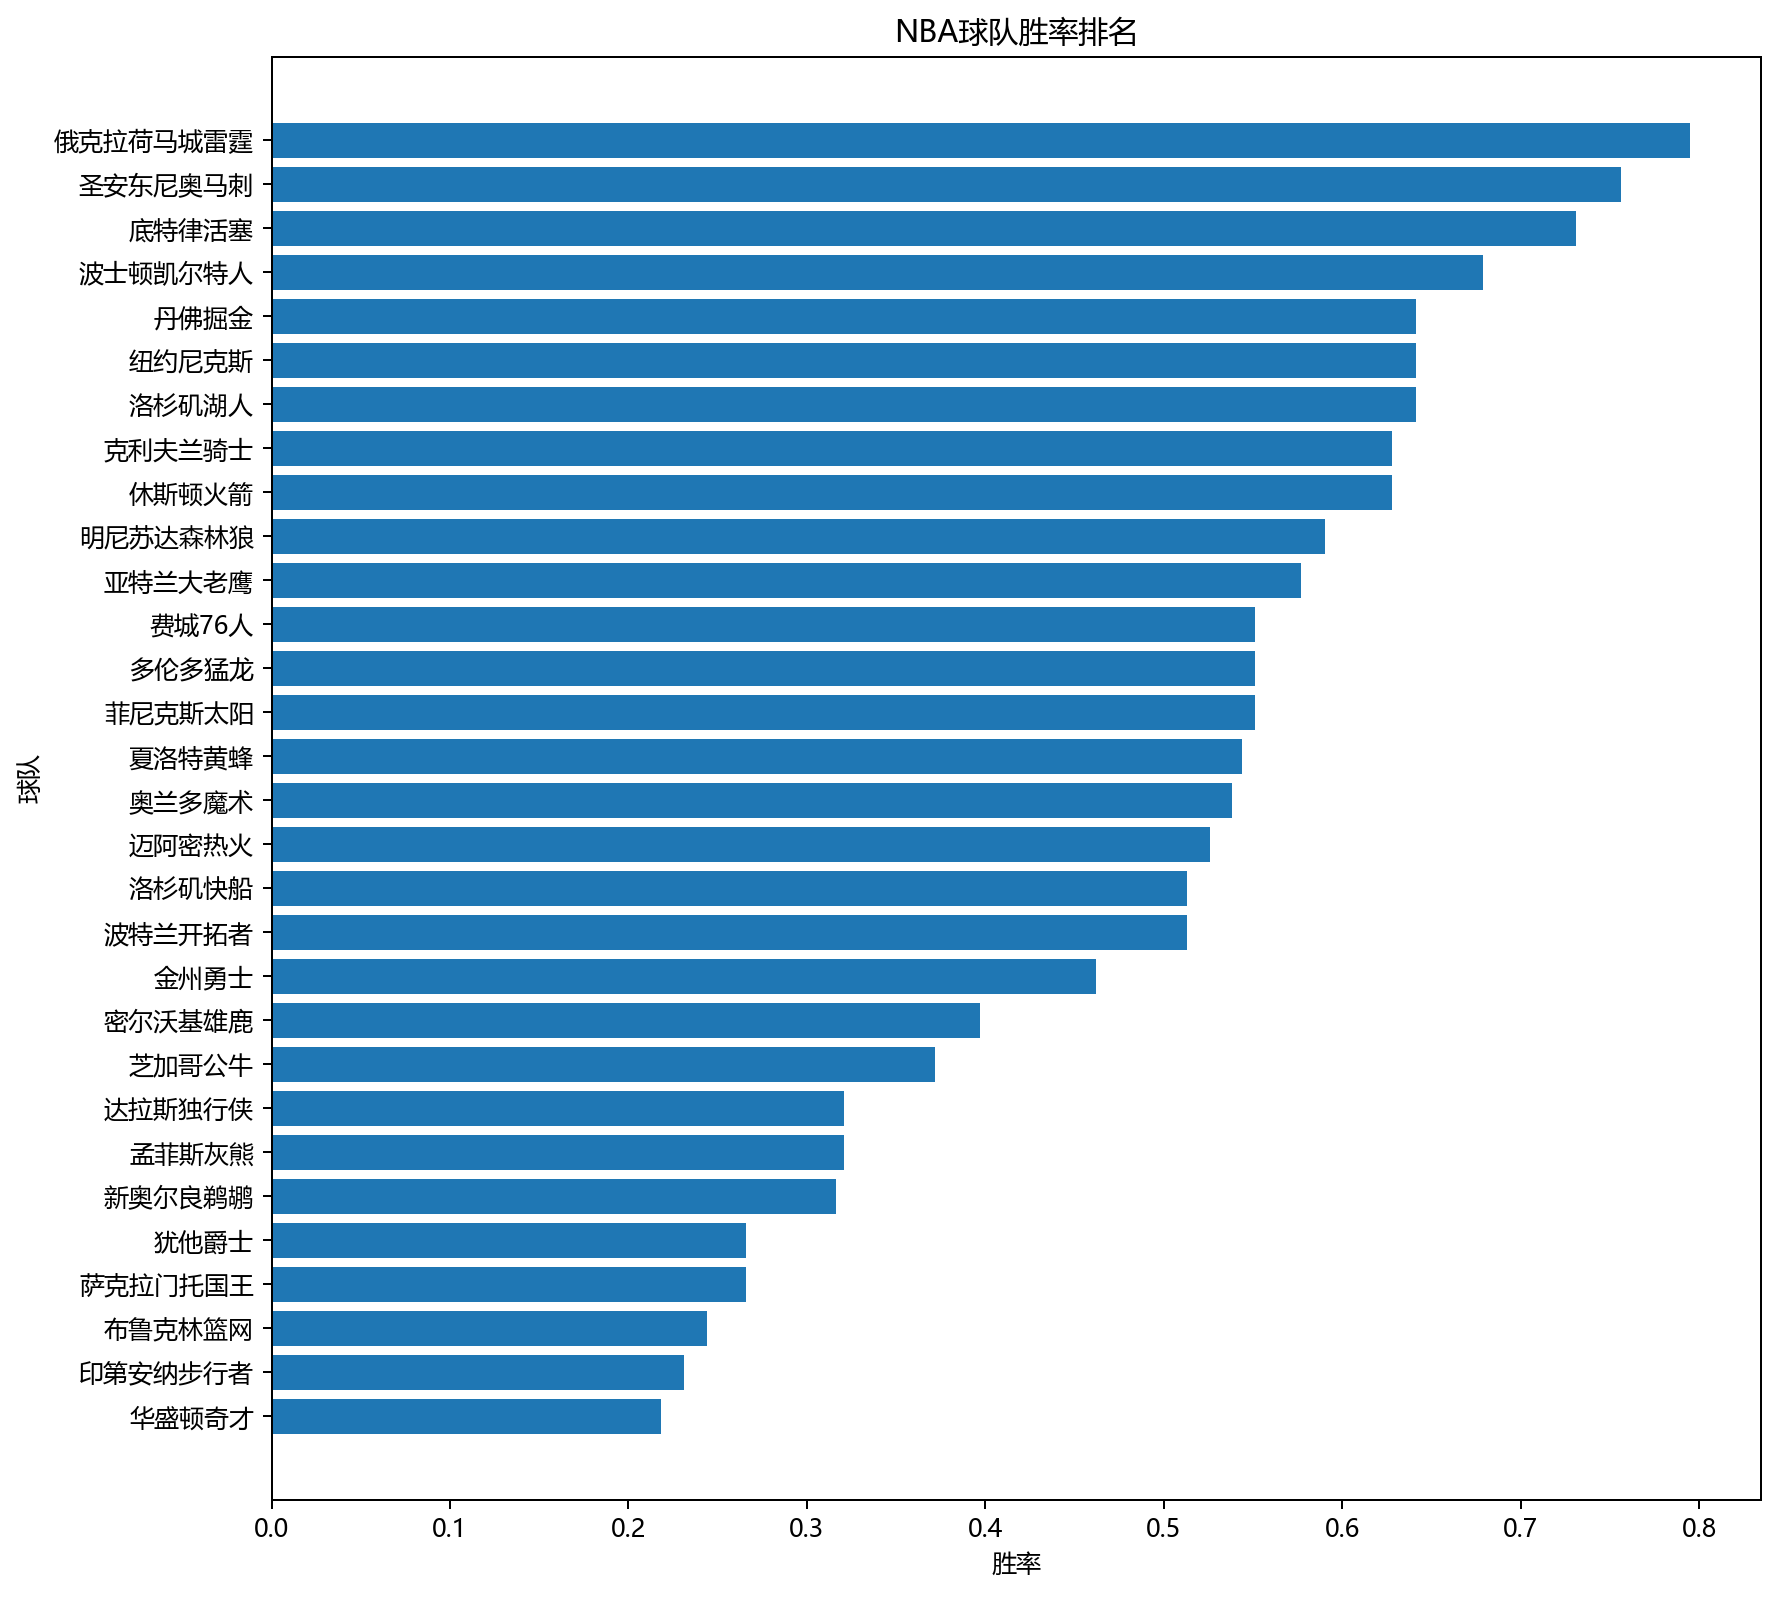

### 图04_净胜分与胜率散点图.png

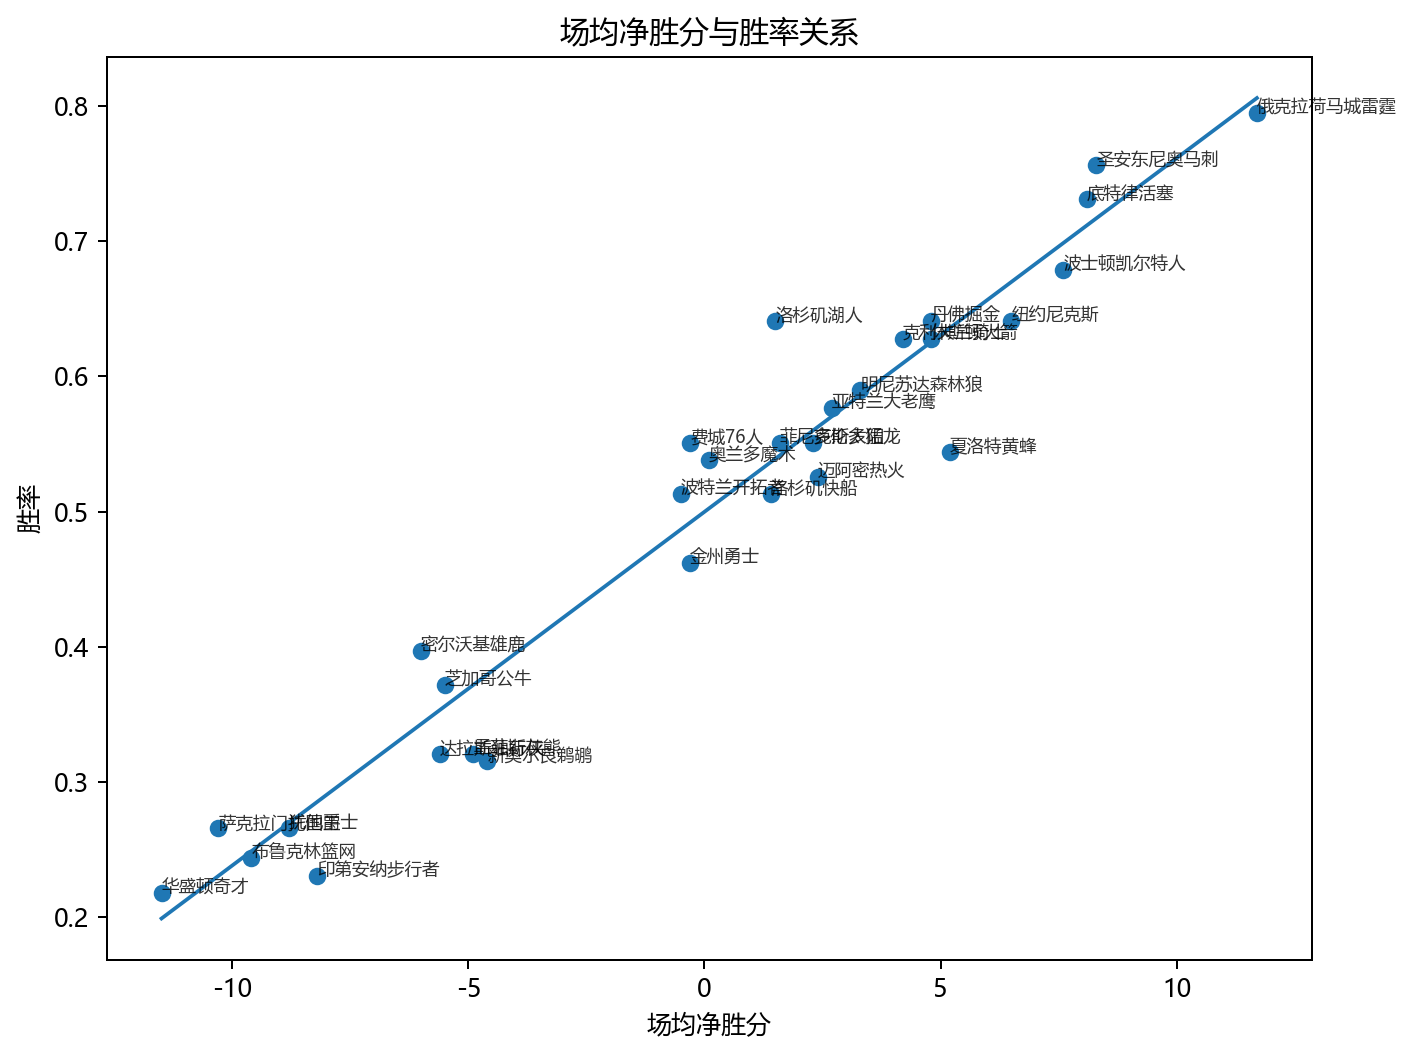

### 图05_强中弱球队标准化指标比较.png

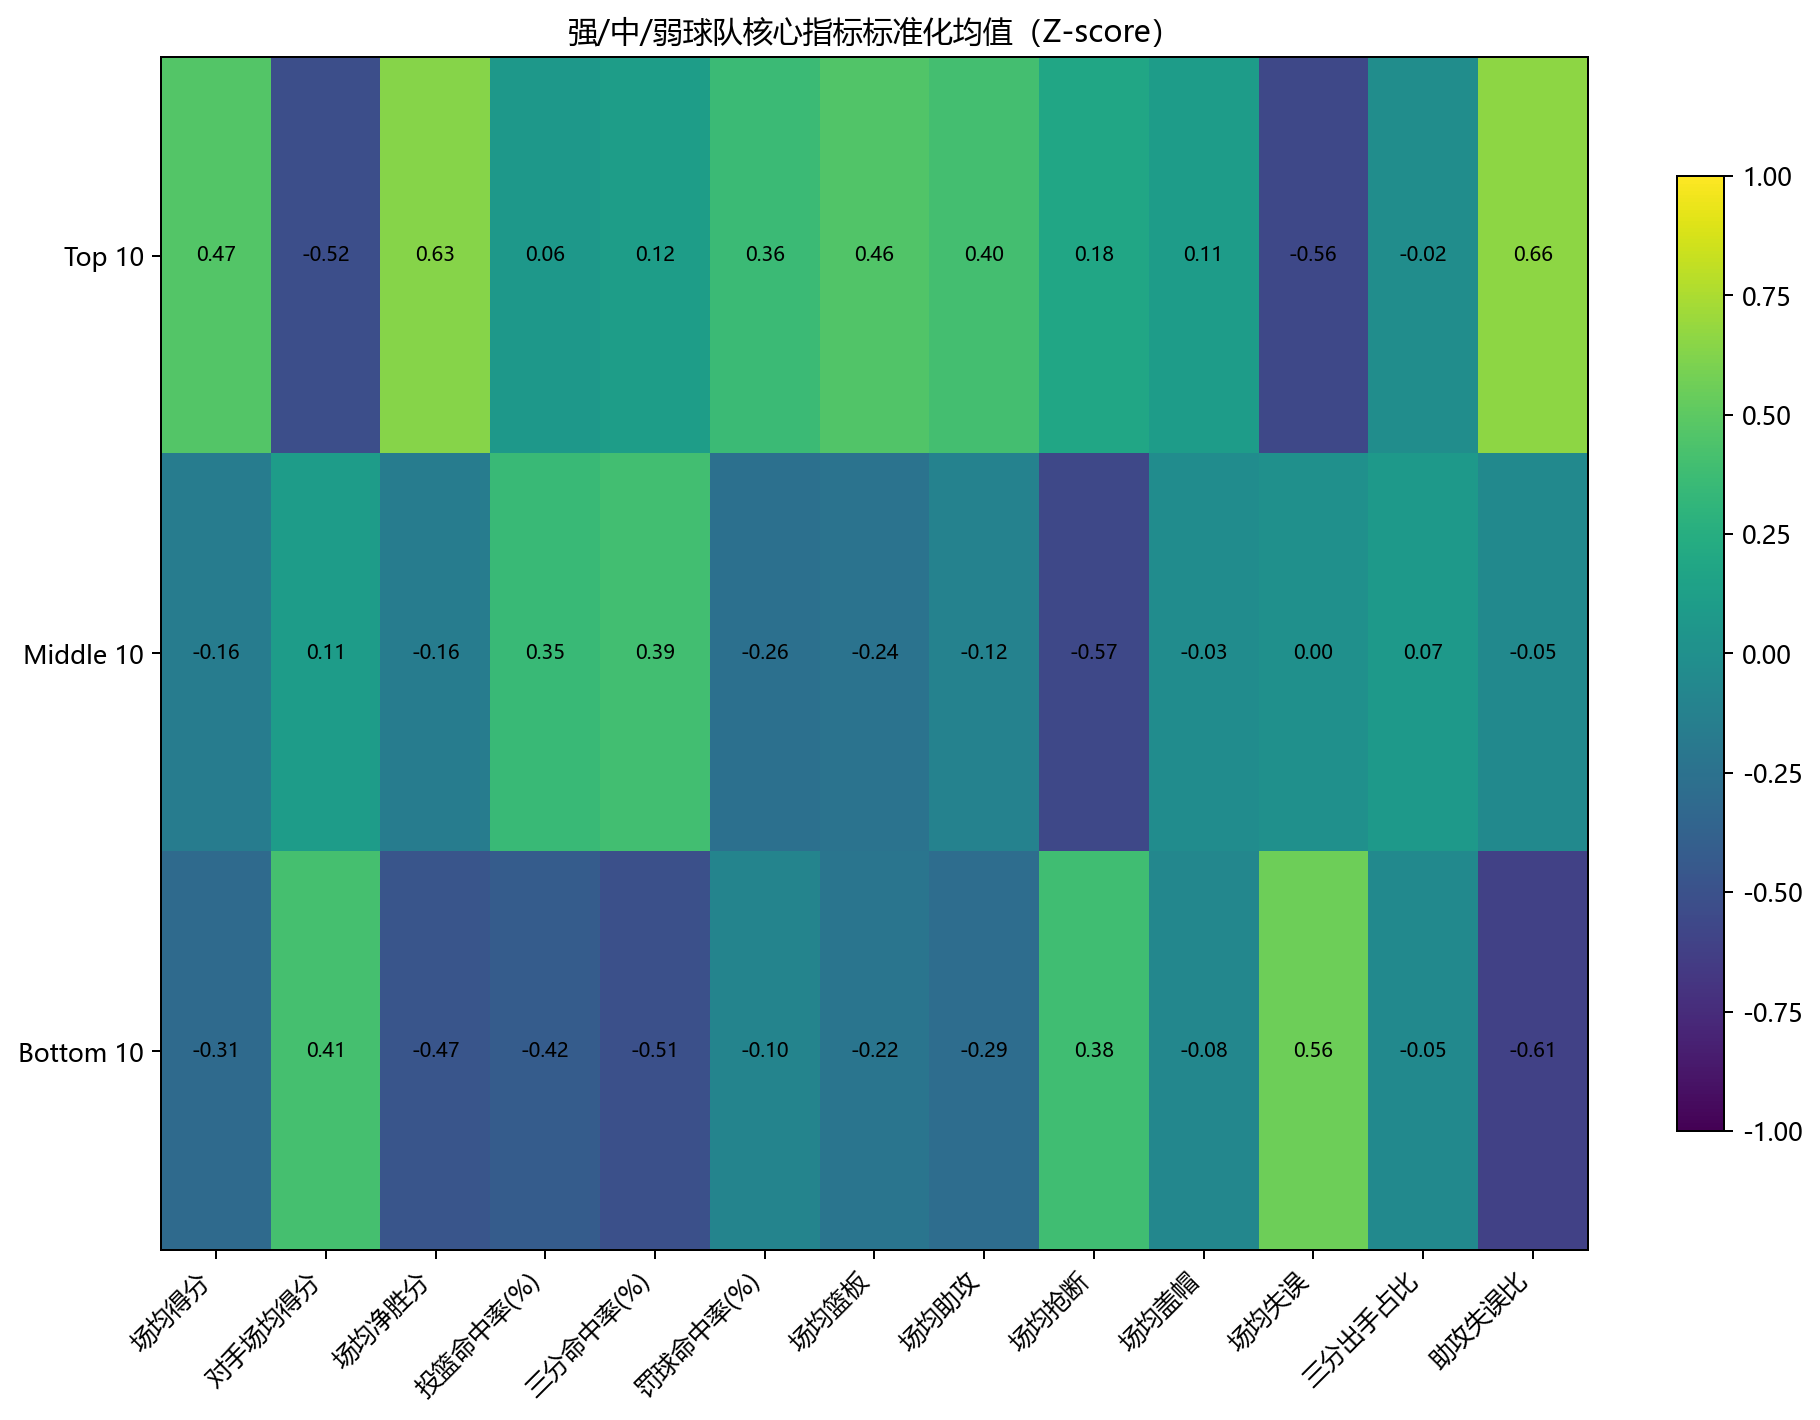

### 图11_球队相关系数热力图.png

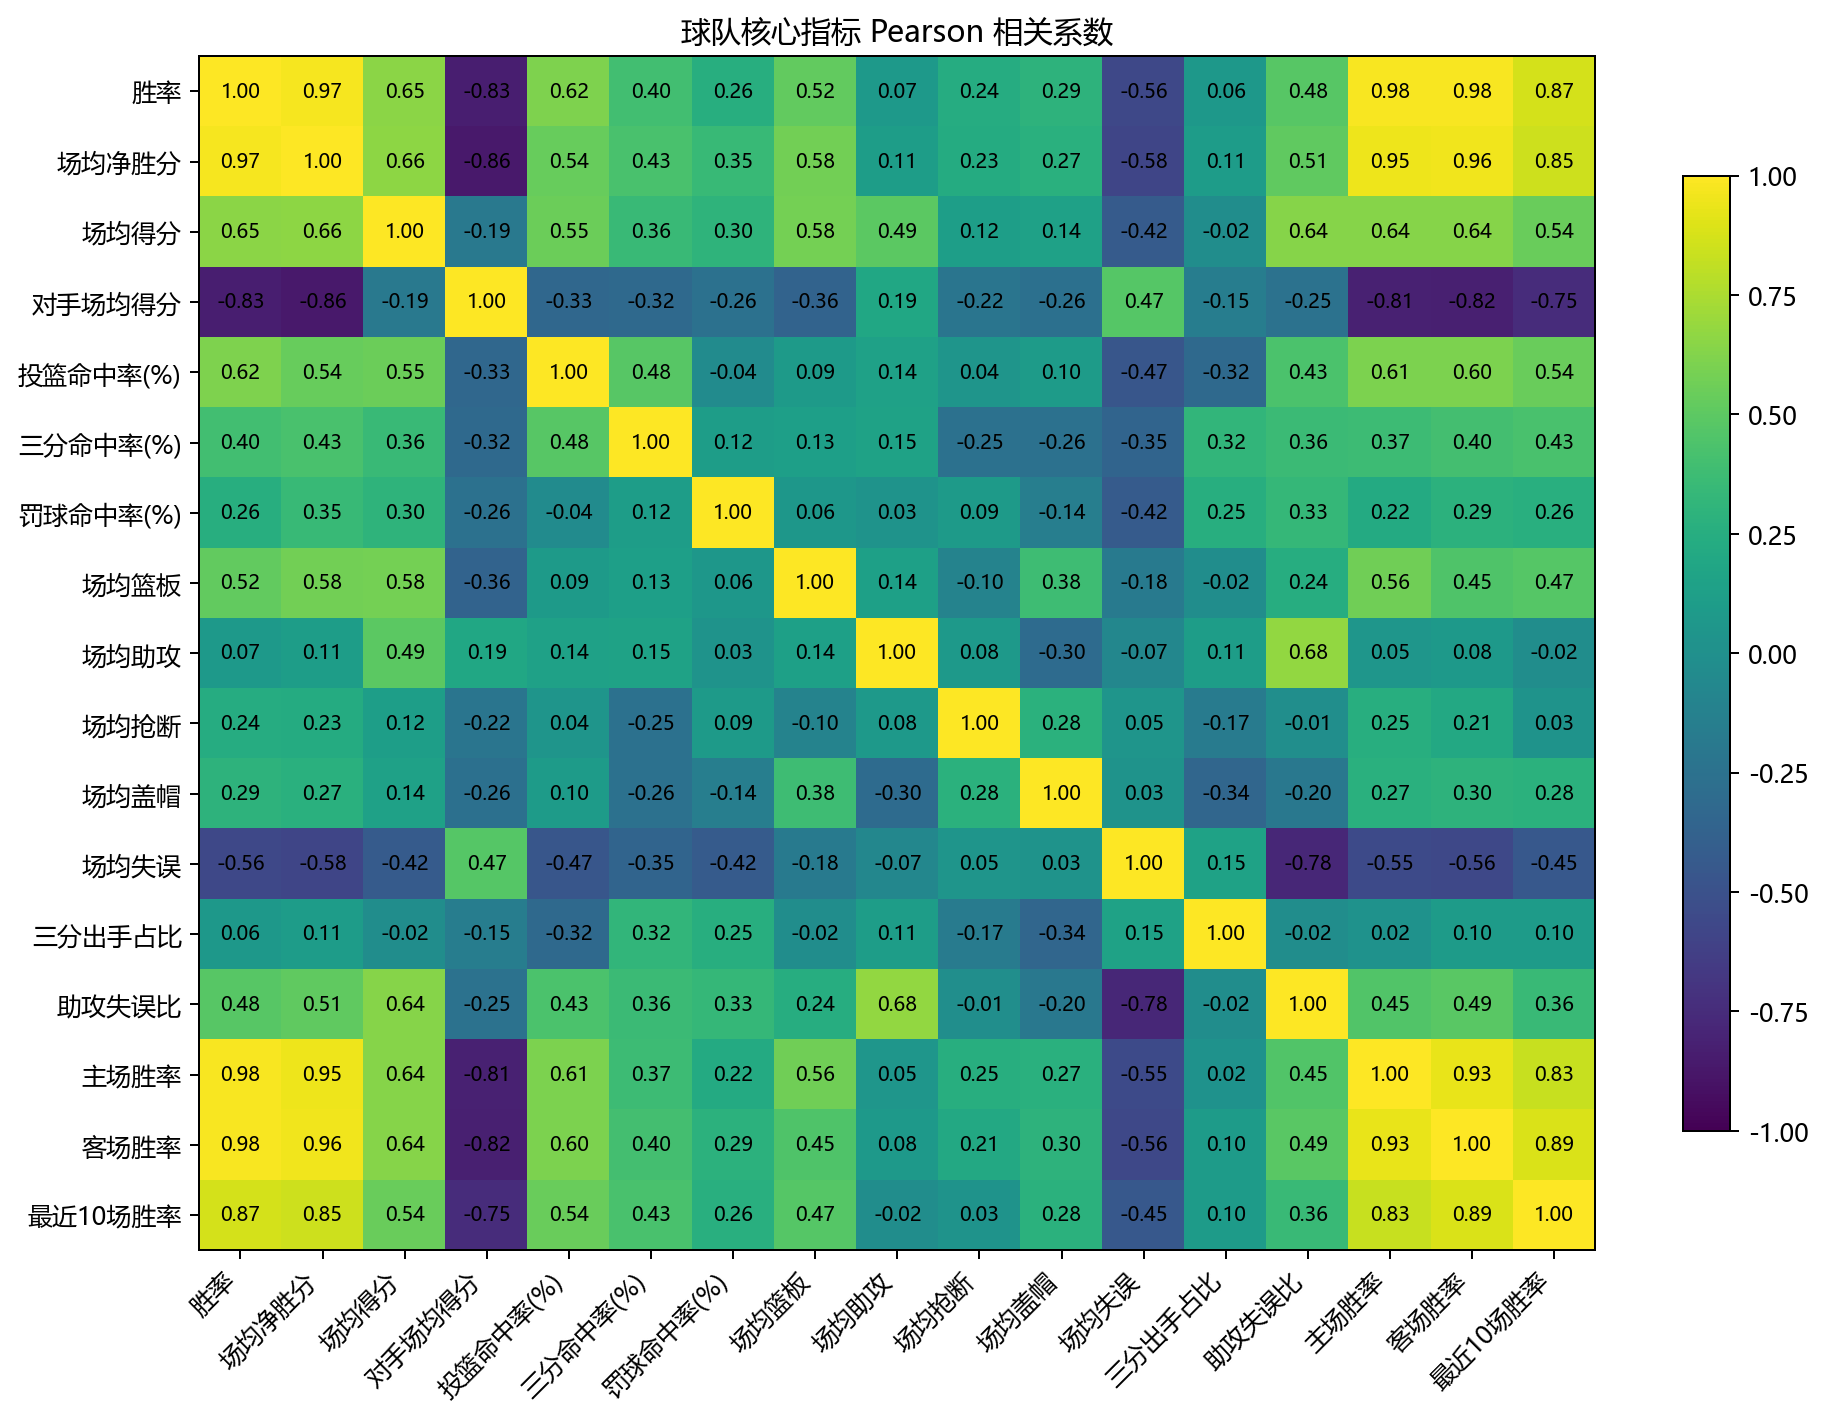

### 图19_主客场胜率散点图.png

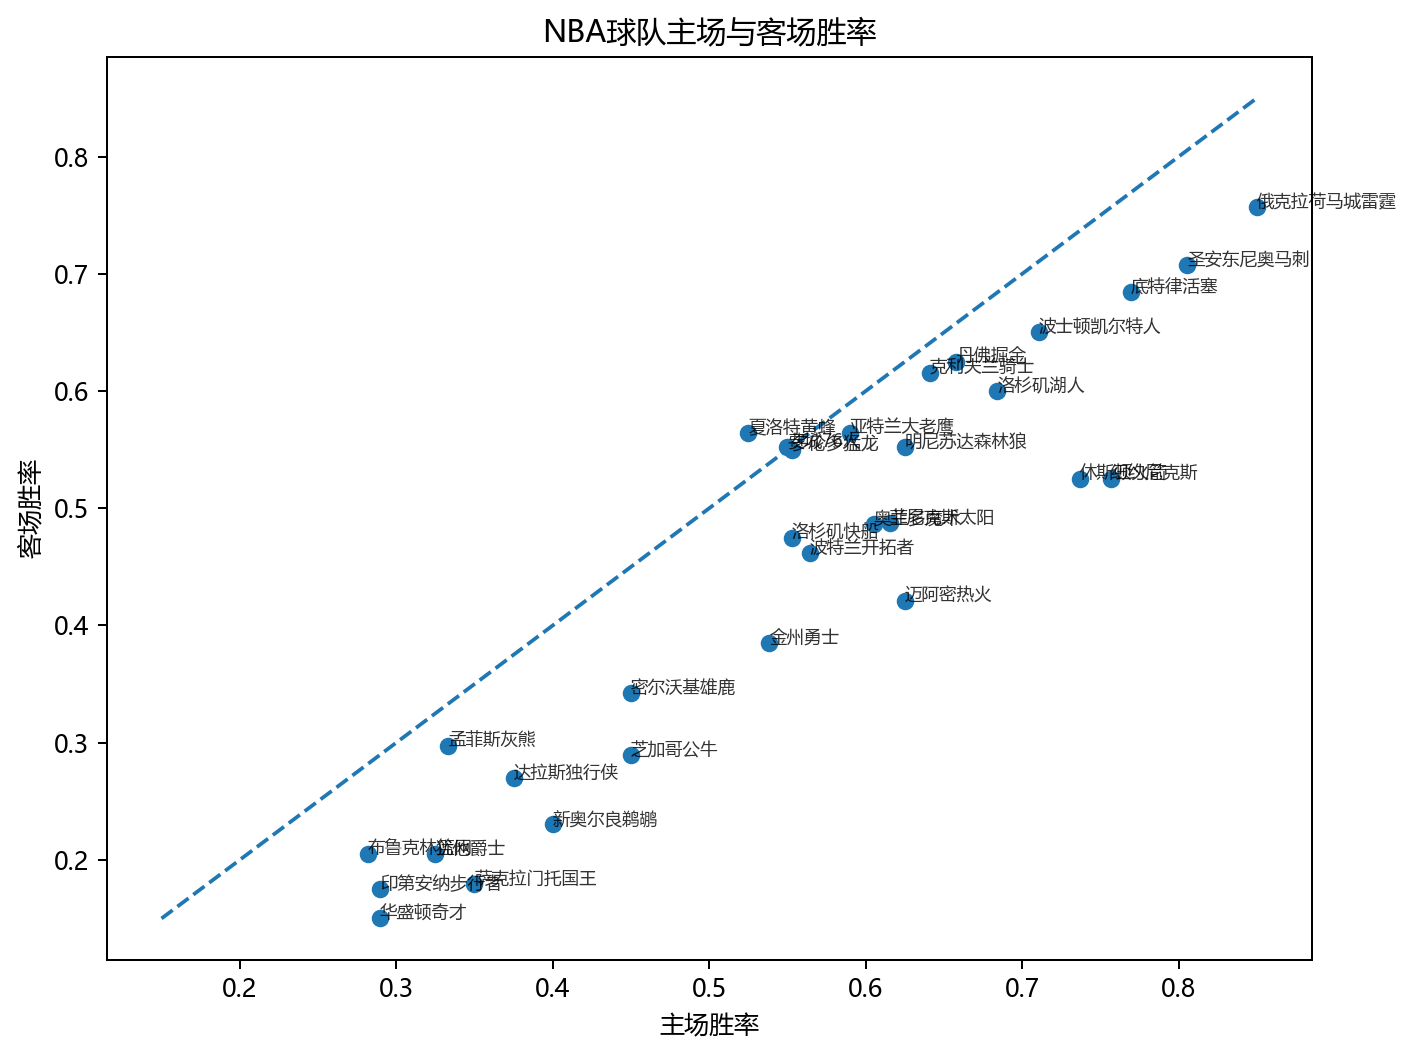

### 图34_球员相关系数热力图.png

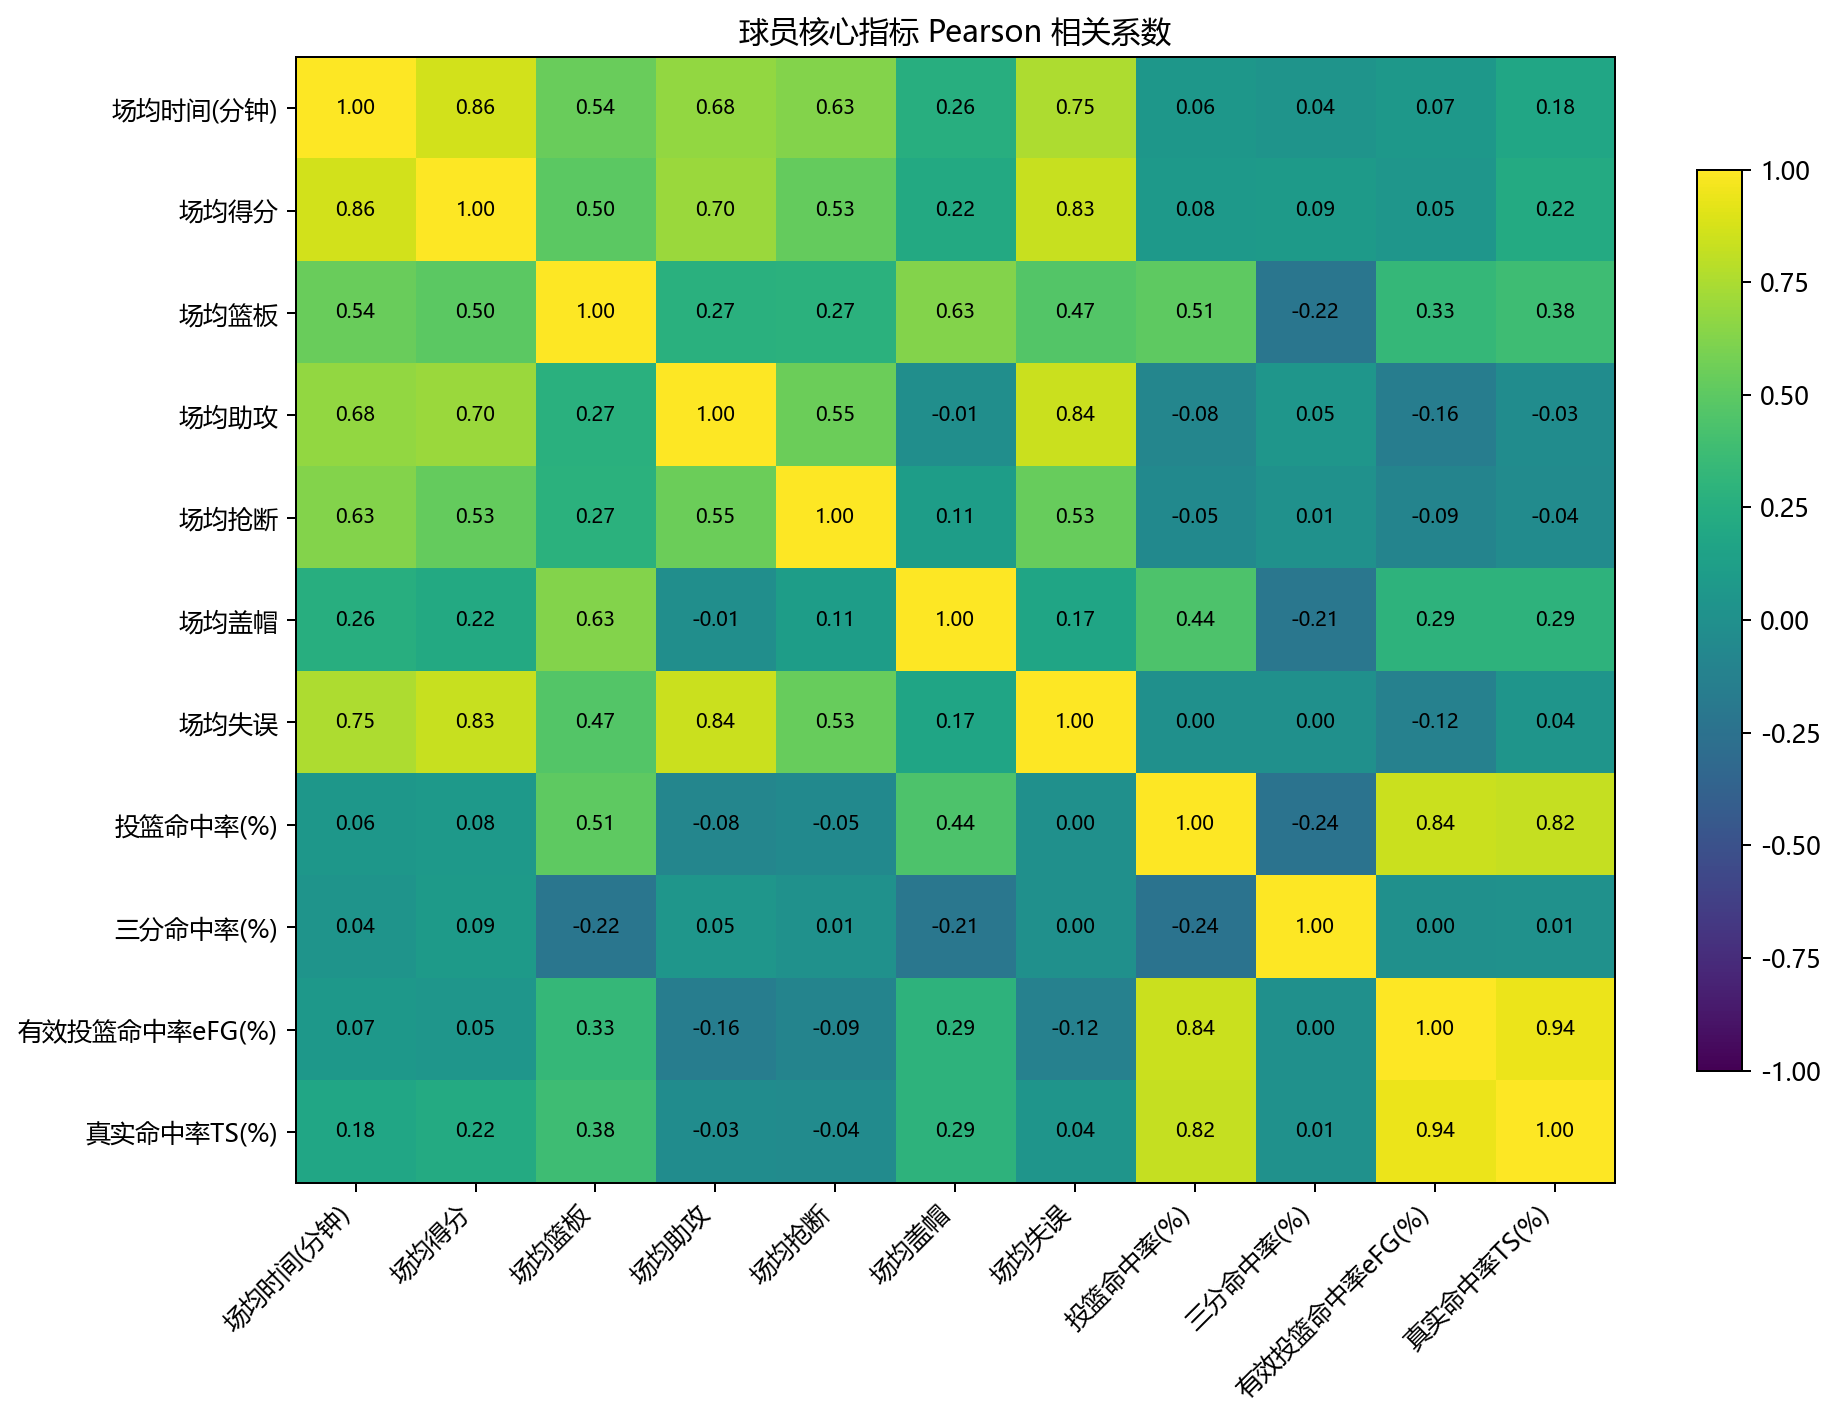

In [17]:
key_analysis_images = [
    "图01_球队胜率排名.png",
    "图04_净胜分与胜率散点图.png",
    "图05_强中弱球队标准化指标比较.png",
    "图11_球队相关系数热力图.png",
    "图19_主客场胜率散点图.png",
    "图34_球员相关系数热力图.png",
]

for name in key_analysis_images:
    p = analysis_dir / name
    if p.exists():
        display(Markdown(f"### {name}"))
        display(Image(filename=str(p)))


# 第二部分：数据挖掘

## 13. 数据挖掘环境与公共函数

这一部分承接前面生成的 `NBA数据分析输出/清洗后_*.csv`。  
如果没有这些文件，程序也会尝试直接从原始 Excel 读取。

In [18]:
# -*- coding: utf-8 -*-
"""
NBA 2025-2026 数据挖掘项目（承接数据分析部分）
=================================================
项目目标：
1. 球队无监督聚类：识别不同球队技术风格
2. 球队 PCA：提取主要竞争特征并二维可视化
3. 球员无监督聚类：识别不同球员角色/风格
4. 球员 PCA：观察球员角色空间结构
5. 球队胜率回归：用纯技术统计预测胜率
6. Top10 强队分类：用纯技术统计识别强队
7. 自动输出结果表、图像和文字摘要

重要原则：
- 预测模型严禁使用 联盟排名、胜场、负场、胜场差、胜率、场均净胜分、
  主/客场战绩、最近10场 等直接或近直接包含赛季结果的信息作为自变量，
  防止“目标泄露（data leakage）”。
- 球队样本只有 30 支，因此回归和分类使用重复交叉验证，结果只作为探索性结论，
  不把高分简单解释为真实泛化能力。
- 聚类前对变量标准化，球员数据额外进行分位数截尾，降低极端值对 K-Means 的影响。

推荐运行方式：
1. 先运行上一份“NBA_2025-2026_数据分析项目_完整源代码.py”；
2. 将本文件与“NBA数据分析输出”文件夹放在同一目录；
3. 在 Anaconda / Spyder 中直接运行本文件。

如果找不到清洗后 CSV，本程序也会尝试从原始 Excel 中读取并做最小必要预处理。

依赖：
pandas, numpy, matplotlib, scikit-learn, openpyxl
Anaconda 一般已包含。
"""

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    silhouette_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
)
from sklearn.model_selection import (
    RepeatedKFold,
    RepeatedStratifiedKFold,
    KFold,
    StratifiedKFold,
    cross_validate,
    cross_val_predict,
)
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyRegressor, DummyClassifier

## 14. 数据挖掘全局设置与辅助函数

In [19]:
# =========================================================
# 0. 全局设置
# =========================================================
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

RANDOM_STATE = 42
OUTPUT_DIR_NAME = "NBA数据挖掘输出"
ANALYSIS_OUTPUT_DIR_NAME = "NBA数据分析输出"


def setup_chinese_font():
    """自动选择常见中文字体，避免图像中文乱码。"""
    candidates = [
        "Microsoft YaHei",
        "SimHei",
        "Noto Sans CJK SC",
        "Source Han Sans CN",
        "Arial Unicode MS",
    ]
    installed = {f.name for f in font_manager.fontManager.ttflist}
    for font_name in candidates:
        if font_name in installed:
            plt.rcParams["font.sans-serif"] = [font_name]
            break
    plt.rcParams["axes.unicode_minus"] = False


def get_base_dir():
    try:
        return Path(__file__).resolve().parent
    except NameError:
        return Path.cwd()


def safe_divide(a, b):
    a = pd.to_numeric(a, errors="coerce")
    b = pd.to_numeric(b, errors="coerce")
    return np.where(b != 0, a / b, np.nan)


def parse_record(series):
    """把 30-9 形式的战绩拆为胜、负、胜率。"""
    temp = series.astype(str).str.extract(r"(\d+)\s*-\s*(\d+)")
    w = pd.to_numeric(temp[0], errors="coerce")
    l = pd.to_numeric(temp[1], errors="coerce")
    pct = safe_divide(w, w + l)
    return w, l, pct


def load_cleaned_or_raw(base_dir):
    """
    优先读取数据分析阶段生成的清洗后数据；
    若不存在，则读取原始 Excel 并完成数据挖掘所需的最小预处理。
    """
    analysis_dir = base_dir / ANALYSIS_OUTPUT_DIR_NAME
    team_clean = analysis_dir / "清洗后_球队综合数据.csv"
    player_clean = analysis_dir / "清洗后_球员数据.csv"

    if team_clean.exists() and player_clean.exists():
        print("[读取] 使用数据分析阶段生成的清洗后 CSV。")
        team = pd.read_csv(team_clean, encoding="utf-8-sig")
        player = pd.read_csv(player_clean, encoding="utf-8-sig")
        return team, player

    print("[提示] 未找到清洗后 CSV，将从原始 Excel 进行最小必要预处理。")
    required_sheets = {"球员数据", "排名数据", "球队数据"}
    excel_file = None
    preferred = [
        "NBA_2025-2026_三表中文版(1).xlsx",
        "NBA_2025-2026_三表中文版.xlsx",
    ]
    for name in preferred:
        p = base_dir / name
        if p.exists():
            excel_file = p
            break
    if excel_file is None:
        for p in base_dir.glob("*.xlsx"):
            try:
                if required_sheets.issubset(set(pd.ExcelFile(p).sheet_names)):
                    excel_file = p
                    break
            except Exception:
                pass
    if excel_file is None:
        raise FileNotFoundError(
            "未找到清洗后数据，也未找到三表中文版 Excel。\n"
            "请先运行数据分析代码，或把 Excel 与本脚本放在同一目录。"
        )

    player = pd.read_excel(excel_file, sheet_name="球员数据")
    standing = pd.read_excel(excel_file, sheet_name="排名数据")
    team_stats = pd.read_excel(excel_file, sheet_name="球队数据")

    # 统一列名：下面兼容当前中文版三表字段。
    # 排名表 + 球队表合并
    team = standing.merge(team_stats, on="球队", how="inner", suffixes=("", "_球队表"))

    # 如果原始排名表还没有衍生字段，则构造。
    if "主场胜率" not in team.columns and "主场战绩" in team.columns:
        team["主场胜场"], team["主场负场"], team["主场胜率"] = parse_record(team["主场战绩"])
    if "客场胜率" not in team.columns and "客场战绩" in team.columns:
        team["客场胜场"], team["客场负场"], team["客场胜率"] = parse_record(team["客场战绩"])

    # 球队特征工程
    if "三分出手占比" not in team.columns:
        team["三分出手占比"] = safe_divide(team["场均三分出手数"], team["场均投篮出手数"])
    if "助攻失误比" not in team.columns:
        team["助攻失误比"] = safe_divide(team["场均助攻"], team["场均失误"])
    if "前场篮板占比" not in team.columns:
        team["前场篮板占比"] = safe_divide(team["场均前场篮板"], team["场均篮板"])
    if "罚球出手率" not in team.columns:
        team["罚球出手率"] = safe_divide(team["场均罚球出手数"], team["场均投篮出手数"])

    # 球员特征工程
    if "原始位置" not in player.columns:
        player["原始位置"] = player["位置"].astype(str)
    if "位置大类" not in player.columns:
        position_map = {
            "后卫": "后卫", "前锋": "前锋", "中锋": "中锋", "大前锋": "前锋",
            "G": "后卫", "F": "前锋", "C": "中锋", "PF": "前锋",
        }
        player["位置大类"] = player["位置"].astype(str).map(position_map).fillna(player["位置"].astype(str))

    minute = pd.to_numeric(player["场均时间(分钟)"], errors="coerce")
    for src, dst in [
        ("场均得分", "每36分钟得分"),
        ("场均篮板", "每36分钟篮板"),
        ("场均助攻", "每36分钟助攻"),
        ("场均抢断", "每36分钟抢断"),
        ("场均盖帽", "每36分钟盖帽"),
        ("场均失误", "每36分钟失误"),
    ]:
        if dst not in player.columns:
            player[dst] = pd.to_numeric(player[src], errors="coerce") * 36 / minute.replace(0, np.nan)

    if "有效投篮命中率eFG(%)" not in player.columns:
        player["有效投篮命中率eFG(%)"] = safe_divide(
            player["场均投篮命中数"] + 0.5 * player["场均三分命中数"],
            player["场均投篮出手数"],
        ) * 100
    if "真实命中率TS(%)" not in player.columns:
        player["真实命中率TS(%)"] = safe_divide(
            player["场均得分"],
            2 * (player["场均投篮出手数"] + 0.44 * player["场均罚球出手数"]),
        ) * 100
    if "三分出手占比" not in player.columns:
        player["三分出手占比"] = safe_divide(player["场均三分出手数"], player["场均投篮出手数"])
    if "助攻失误比" not in player.columns:
        player["助攻失误比"] = safe_divide(player["场均助攻"], player["场均失误"])

    return team, player


def ensure_numeric(df, columns):
    out = df.copy()
    for c in columns:
        if c in out.columns:
            out[c] = pd.to_numeric(out[c], errors="coerce")
    return out


def save_csv(df, path):
    df.to_csv(path, index=False, encoding="utf-8-sig")


def save_figure(path):
    plt.tight_layout()
    plt.savefig(path, dpi=220, bbox_inches="tight")
    plt.close()


def winsorize_frame(df, cols, lower=0.01, upper=0.99):
    """按列分位数截尾，降低极端值对 K-Means 的影响。"""
    out = df.copy()
    for c in cols:
        lo = out[c].quantile(lower)
        hi = out[c].quantile(upper)
        out[c] = out[c].clip(lo, hi)
    return out


def kmeans_select_k(X_scaled, k_values):
    rows = []
    for k in k_values:
        model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=50)
        labels = model.fit_predict(X_scaled)
        score = silhouette_score(X_scaled, labels)
        rows.append({"K值": k, "轮廓系数": score, "簇内平方和Inertia": model.inertia_})
    result = pd.DataFrame(rows)
    best_k = int(result.loc[result["轮廓系数"].idxmax(), "K值"])
    return result, best_k


def make_cluster_profile(z_df, labels, feature_names):
    """生成每个聚类相对总体均值的高低画像（基于标准化均值）。"""
    temp = z_df.copy()
    temp["聚类"] = labels
    centers_z = temp.groupby("聚类")[feature_names].mean()
    profiles = []
    for cluster_id, row in centers_z.iterrows():
        s = row.sort_values(ascending=False)
        high = "、".join([f"{idx}({val:+.2f}σ)" for idx, val in s.head(3).items()])
        low_s = row.sort_values(ascending=True)
        low = "、".join([f"{idx}({val:+.2f}σ)" for idx, val in low_s.head(3).items()])
        profiles.append({"聚类": cluster_id, "相对突出指标": high, "相对偏低指标": low})
    return pd.DataFrame(profiles), centers_z

## 15. 球队 K-Means 聚类 + PCA

In [20]:
# =========================================================
# 1. 球队聚类 + PCA
# =========================================================
def team_clustering(team, output_dir):
    print("\n========== 1. 球队聚类与 PCA ==========")

    features = [
        "场均得分",
        "投篮命中率(%)",
        "三分命中率(%)",
        "场均篮板",
        "场均助攻",
        "场均抢断",
        "场均盖帽",
        "场均失误",
        "三分出手占比",
        "助攻失误比",
    ]
    team = ensure_numeric(team, features + ["胜率", "联盟排名"])
    use = team[["球队", "分区", "联盟排名", "胜率"] + features].dropna().copy()

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(use[features])

    k_eval, best_k = kmeans_select_k(X_scaled, range(2, 7))
    save_csv(k_eval, output_dir / "01_球队聚类_K值评估.csv")
    print(f"球队聚类自动选择 K = {best_k}，依据为轮廓系数最大。")

    model = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=100)
    labels = model.fit_predict(X_scaled)
    use["球队聚类"] = labels + 1

    # PCA 二维投影
    pca = PCA(n_components=min(len(features), len(use)))
    pcs = pca.fit_transform(X_scaled)
    use["PC1"] = pcs[:, 0]
    use["PC2"] = pcs[:, 1]

    save_csv(use.sort_values(["球队聚类", "联盟排名"]), output_dir / "02_球队聚类结果.csv")

    centers_raw = pd.DataFrame(
        scaler.inverse_transform(model.cluster_centers_),
        columns=features,
    )
    centers_raw.insert(0, "球队聚类", np.arange(1, best_k + 1))
    save_csv(centers_raw, output_dir / "03_球队聚类中心_原始尺度.csv")

    z_df = pd.DataFrame(X_scaled, columns=features, index=use.index)
    profile, centers_z = make_cluster_profile(z_df, labels + 1, features)
    counts = use["球队聚类"].value_counts().sort_index().rename("球队数")
    avg_result = use.groupby("球队聚类")[["胜率", "联盟排名"]].mean().rename(
        columns={"胜率": "平均胜率", "联盟排名": "平均联盟排名"}
    )
    profile = profile.merge(counts, left_on="聚类", right_index=True).merge(avg_result, left_on="聚类", right_index=True)
    save_csv(profile, output_dir / "04_球队聚类画像.csv")

    # PCA 解释率、载荷
    pca_info = pd.DataFrame({
        "主成分": [f"PC{i+1}" for i in range(len(pca.explained_variance_ratio_))],
        "方差解释率": pca.explained_variance_ratio_,
        "累计解释率": np.cumsum(pca.explained_variance_ratio_),
    })
    save_csv(pca_info, output_dir / "05_球队PCA_解释方差.csv")

    loadings = pd.DataFrame(
        pca.components_.T,
        index=features,
        columns=[f"PC{i+1}" for i in range(pca.n_components_)],
    ).reset_index().rename(columns={"index": "指标"})
    save_csv(loadings, output_dir / "06_球队PCA_载荷矩阵.csv")

    # 图1：K 选择
    plt.figure(figsize=(7, 5))
    plt.plot(k_eval["K值"], k_eval["轮廓系数"], marker="o")
    plt.axvline(best_k, linestyle="--", alpha=0.6)
    plt.xlabel("聚类数 K")
    plt.ylabel("轮廓系数")
    plt.title("球队 K-Means 聚类数选择")
    plt.grid(alpha=0.2)
    save_figure(output_dir / "图01_球队聚类_K值选择.png")

    # 图2：PCA 聚类散点图
    plt.figure(figsize=(10, 7))
    for cid in sorted(use["球队聚类"].unique()):
        part = use[use["球队聚类"] == cid]
        plt.scatter(part["PC1"], part["PC2"], s=75, label=f"聚类{cid}", alpha=0.8)
    for _, row in use.iterrows():
        plt.annotate(row["球队"], (row["PC1"], row["PC2"]), fontsize=8, xytext=(3, 3), textcoords="offset points")
    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
    plt.title("球队技术风格聚类：PCA 二维投影")
    plt.legend()
    plt.grid(alpha=0.2)
    save_figure(output_dir / "图02_球队聚类_PCA二维图.png")

    # 图3：标准化聚类中心画像
    center_plot = centers_z.copy()
    center_plot.index = [f"聚类{i}" for i in center_plot.index]
    plt.figure(figsize=(12, 5 + 0.5 * best_k))
    im = plt.imshow(center_plot.values, aspect="auto", cmap="coolwarm", vmin=-2, vmax=2)
    plt.colorbar(im, label="标准化均值（Z-score）")
    plt.xticks(range(len(features)), features, rotation=45, ha="right")
    plt.yticks(range(best_k), center_plot.index)
    plt.title("球队聚类中心画像（相对联盟平均水平）")
    for i in range(best_k):
        for j in range(len(features)):
            plt.text(j, i, f"{center_plot.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7)
    save_figure(output_dir / "图03_球队聚类中心画像.png")

    return {
        "best_k": best_k,
        "silhouette": float(k_eval.loc[k_eval["K值"] == best_k, "轮廓系数"].iloc[0]),
        "pca2": float(pca.explained_variance_ratio_[:2].sum()),
        "features": features,
        "result": use,
        "profile": profile,
    }

## 16. 球员 K-Means 聚类 + PCA

In [21]:
# =========================================================
# 2. 球员聚类 + PCA
# =========================================================
def player_clustering(player, output_dir):
    print("\n========== 2. 球员聚类与 PCA ==========")

    # 过滤极低样本球员，避免少量出场导致每36分钟数据被放大。
    min_gp = 20
    min_min = 10
    features = [
        "每36分钟得分",
        "每36分钟篮板",
        "每36分钟助攻",
        "每36分钟抢断",
        "每36分钟盖帽",
        "每36分钟失误",
        "真实命中率TS(%)",
        "三分出手占比",
        "助攻失误比",
    ]

    player = ensure_numeric(player, features + ["出场次数", "场均时间(分钟)", "场均得分", "场均篮板", "场均助攻"])
    base_cols = ["球员姓名", "位置大类", "出场次数", "场均时间(分钟)", "场均得分", "场均篮板", "场均助攻"]
    use = player.loc[
        (player["出场次数"] >= min_gp) & (player["场均时间(分钟)"] >= min_min),
        base_cols + features,
    ].dropna().copy()

    # 1%-99% 截尾减少极端比例指标的影响
    work = winsorize_frame(use, features, 0.01, 0.99)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(work[features])

    k_eval, best_k = kmeans_select_k(X_scaled, range(3, 7))
    save_csv(k_eval, output_dir / "07_球员聚类_K值评估.csv")
    print(f"纳入球员 {len(use)} 人；自动选择 K = {best_k}。")

    model = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=100)
    labels = model.fit_predict(X_scaled)
    use["球员聚类"] = labels + 1

    pca = PCA(n_components=min(len(features), len(use)))
    pcs = pca.fit_transform(X_scaled)
    use["PC1"] = pcs[:, 0]
    use["PC2"] = pcs[:, 1]
    save_csv(use.sort_values(["球员聚类", "场均得分"], ascending=[True, False]), output_dir / "08_球员聚类结果.csv")

    centers_raw = pd.DataFrame(scaler.inverse_transform(model.cluster_centers_), columns=features)
    centers_raw.insert(0, "球员聚类", np.arange(1, best_k + 1))
    save_csv(centers_raw, output_dir / "09_球员聚类中心_原始尺度.csv")

    z_df = pd.DataFrame(X_scaled, columns=features, index=use.index)
    profile, centers_z = make_cluster_profile(z_df, labels + 1, features)
    counts = use["球员聚类"].value_counts().sort_index().rename("球员数")
    profile = profile.merge(counts, left_on="聚类", right_index=True)
    save_csv(profile, output_dir / "10_球员聚类画像.csv")

    # 位置构成：帮助解释聚类角色，但不参与聚类本身。
    pos_dist = pd.crosstab(use["球员聚类"], use["位置大类"], normalize="index") * 100
    pos_dist = pos_dist.round(2).reset_index()
    save_csv(pos_dist, output_dir / "11_各球员聚类_位置构成百分比.csv")

    pca_info = pd.DataFrame({
        "主成分": [f"PC{i+1}" for i in range(len(pca.explained_variance_ratio_))],
        "方差解释率": pca.explained_variance_ratio_,
        "累计解释率": np.cumsum(pca.explained_variance_ratio_),
    })
    save_csv(pca_info, output_dir / "12_球员PCA_解释方差.csv")
    loadings = pd.DataFrame(
        pca.components_.T,
        index=features,
        columns=[f"PC{i+1}" for i in range(pca.n_components_)],
    ).reset_index().rename(columns={"index": "指标"})
    save_csv(loadings, output_dir / "13_球员PCA_载荷矩阵.csv")

    # K 选择图
    plt.figure(figsize=(7, 5))
    plt.plot(k_eval["K值"], k_eval["轮廓系数"], marker="o")
    plt.axvline(best_k, linestyle="--", alpha=0.6)
    plt.xlabel("聚类数 K")
    plt.ylabel("轮廓系数")
    plt.title("球员 K-Means 聚类数选择")
    plt.grid(alpha=0.2)
    save_figure(output_dir / "图04_球员聚类_K值选择.png")

    # PCA 聚类图
    plt.figure(figsize=(10, 7))
    for cid in sorted(use["球员聚类"].unique()):
        part = use[use["球员聚类"] == cid]
        plt.scatter(part["PC1"], part["PC2"], s=35, label=f"聚类{cid}", alpha=0.7)
    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
    plt.title("球员角色聚类：PCA 二维投影")
    plt.legend()
    plt.grid(alpha=0.2)
    save_figure(output_dir / "图05_球员聚类_PCA二维图.png")

    # 聚类中心画像
    center_plot = centers_z.copy()
    center_plot.index = [f"聚类{i}" for i in center_plot.index]
    plt.figure(figsize=(12, 5 + 0.5 * best_k))
    im = plt.imshow(center_plot.values, aspect="auto", cmap="coolwarm", vmin=-2, vmax=2)
    plt.colorbar(im, label="标准化均值（Z-score）")
    plt.xticks(range(len(features)), features, rotation=45, ha="right")
    plt.yticks(range(best_k), center_plot.index)
    plt.title("球员聚类中心画像")
    for i in range(best_k):
        for j in range(len(features)):
            plt.text(j, i, f"{center_plot.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7)
    save_figure(output_dir / "图06_球员聚类中心画像.png")

    return {
        "n_players": len(use),
        "best_k": best_k,
        "silhouette": float(k_eval.loc[k_eval["K值"] == best_k, "轮廓系数"].iloc[0]),
        "pca2": float(pca.explained_variance_ratio_[:2].sum()),
        "result": use,
        "profile": profile,
    }

## 17. 球队胜率回归

In [22]:
# =========================================================
# 3. 球队胜率回归
# =========================================================
def team_winrate_regression(team, output_dir):
    print("\n========== 3. 球队胜率回归 ==========")

    features = [
        "场均得分",
        "投篮命中率(%)",
        "三分命中率(%)",
        "罚球命中率(%)",
        "场均篮板",
        "场均助攻",
        "场均抢断",
        "场均盖帽",
        "场均失误",
        "三分出手占比",
        "助攻失误比",
        "罚球出手率",
    ]
    target = "胜率"
    team = ensure_numeric(team, features + [target])
    use = team[["球队", "联盟排名", target] + features].dropna().copy()
    X = use[features]
    y = use[target]

    # 5 折交叉验证：在 30 支球队的小样本条件下评估模型。
    cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    alphas = np.logspace(-3, 3, 60)

    models = {
        "均值基线": DummyRegressor(strategy="mean"),
        "线性回归": Pipeline([
            ("scale", StandardScaler()),
            ("model", LinearRegression()),
        ]),
        "岭回归": Pipeline([
            ("scale", StandardScaler()),
            ("model", RidgeCV(alphas=alphas)),
        ]),
        "随机森林回归": RandomForestRegressor(
            n_estimators=120,
            max_depth=4,
            min_samples_leaf=2,
            random_state=RANDOM_STATE,
        ),
        "梯度提升回归": GradientBoostingRegressor(
            n_estimators=80,
            learning_rate=0.03,
            max_depth=2,
            random_state=RANDOM_STATE,
            loss="huber",
        ),
    }

    scoring = {
        "MAE": "neg_mean_absolute_error",
        "RMSE": "neg_root_mean_squared_error",
        "R2": "r2",
    }
    rows = []
    for name, model in models.items():
        score = cross_validate(model, X, y, cv=cv, scoring=scoring, n_jobs=1)
        rows.append({
            "模型": name,
            "CV_MAE均值": -score["test_MAE"].mean(),
            "CV_MAE标准差": score["test_MAE"].std(),
            "CV_RMSE均值": -score["test_RMSE"].mean(),
            "CV_RMSE标准差": score["test_RMSE"].std(),
            "CV_R2均值": score["test_R2"].mean(),
            "CV_R2标准差": score["test_R2"].std(),
        })
    compare = pd.DataFrame(rows).sort_values("CV_RMSE均值")
    save_csv(compare, output_dir / "14_胜率回归_模型交叉验证比较.csv")

    # 岭回归作为主解释模型：在全样本拟合后查看标准化系数。
    ridge_pipe = Pipeline([
        ("scale", StandardScaler()),
        ("model", RidgeCV(alphas=alphas)),
    ])
    ridge_pipe.fit(X, y)
    ridge = ridge_pipe.named_steps["model"]
    coef = pd.DataFrame({
        "指标": features,
        "标准化岭回归系数": ridge.coef_,
        "系数绝对值": np.abs(ridge.coef_),
    }).sort_values("系数绝对值", ascending=False)
    coef["方向"] = np.where(coef["标准化岭回归系数"] >= 0, "正向", "负向")
    save_csv(coef, output_dir / "15_胜率回归_岭回归标准化系数.csv")

    # 5折 OOF 预测用于直观展示（每支球队仅被预测一次）
    cv_pred = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    pred = cross_val_predict(ridge_pipe, X, y, cv=cv_pred, n_jobs=1)
    pred_df = use[["球队", "联盟排名", target]].copy()
    pred_df["交叉验证预测胜率"] = pred
    pred_df["预测误差"] = pred_df["交叉验证预测胜率"] - pred_df[target]
    pred_df["绝对误差"] = pred_df["预测误差"].abs()
    save_csv(pred_df.sort_values("绝对误差", ascending=False), output_dir / "16_胜率回归_岭回归OOF预测.csv")

    oof_mae = mean_absolute_error(y, pred)
    oof_rmse = np.sqrt(mean_squared_error(y, pred))
    oof_r2 = r2_score(y, pred)

    # 图：模型比较
    plt.figure(figsize=(9, 5))
    order = compare.sort_values("CV_RMSE均值")
    plt.barh(order["模型"], order["CV_RMSE均值"], xerr=order["CV_RMSE标准差"], alpha=0.8)
    plt.xlabel("5折交叉验证 RMSE（越低越好）")
    plt.title("球队胜率回归模型比较")
    save_figure(output_dir / "图07_胜率回归模型比较.png")

    # 图：实际 vs 预测
    plt.figure(figsize=(7, 6))
    plt.scatter(y, pred, s=70, alpha=0.8)
    lo = min(y.min(), pred.min())
    hi = max(y.max(), pred.max())
    plt.plot([lo, hi], [lo, hi], linestyle="--")
    for i, row in use.reset_index(drop=True).iterrows():
        plt.annotate(row["球队"], (y.iloc[i], pred[i]), fontsize=7, xytext=(3, 3), textcoords="offset points")
    plt.xlabel("真实胜率")
    plt.ylabel("交叉验证预测胜率")
    plt.title(f"岭回归：真实胜率 vs 预测胜率\nMAE={oof_mae:.3f}, RMSE={oof_rmse:.3f}, R²={oof_r2:.3f}")
    plt.grid(alpha=0.2)
    save_figure(output_dir / "图08_岭回归_真实胜率与预测胜率.png")

    # 图：系数
    plot_coef = coef.sort_values("标准化岭回归系数")
    plt.figure(figsize=(9, 6))
    plt.barh(plot_coef["指标"], plot_coef["标准化岭回归系数"])
    plt.axvline(0, linewidth=1)
    plt.xlabel("标准化岭回归系数")
    plt.title("球队技术指标与胜率的岭回归系数（探索性）")
    save_figure(output_dir / "图09_胜率回归_岭回归系数.png")

    return {
        "compare": compare,
        "alpha": float(ridge.alpha_),
        "oof_mae": float(oof_mae),
        "oof_rmse": float(oof_rmse),
        "oof_r2": float(oof_r2),
        "coef": coef,
    }

## 18. Top10 强队分类

In [23]:
# =========================================================
# 4. Top10 强队分类
# =========================================================
def top10_classification(team, output_dir):
    print("\n========== 4. Top10 强队分类 ==========")

    features = [
        "场均得分",
        "投篮命中率(%)",
        "三分命中率(%)",
        "罚球命中率(%)",
        "场均篮板",
        "场均助攻",
        "场均抢断",
        "场均盖帽",
        "场均失误",
        "三分出手占比",
        "助攻失误比",
        "罚球出手率",
    ]
    team = ensure_numeric(team, features + ["联盟排名", "胜率"])
    use = team[["球队", "联盟排名", "胜率"] + features].dropna().copy()
    use["是否Top10"] = (use["联盟排名"] <= 10).astype(int)
    X = use[features]
    y = use["是否Top10"]

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    models = {
        "多数类基线": DummyClassifier(strategy="most_frequent"),
        "逻辑回归": Pipeline([
            ("scale", StandardScaler()),
            ("model", LogisticRegression(C=1.0, class_weight="balanced", max_iter=3000, random_state=RANDOM_STATE)),
        ]),
        "决策树": DecisionTreeClassifier(
            max_depth=3,
            min_samples_leaf=3,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        ),
        "随机森林分类": RandomForestClassifier(
            n_estimators=120,
            max_depth=4,
            min_samples_leaf=2,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        ),
    }

    scoring = {
        "Accuracy": "accuracy",
        "BalancedAccuracy": "balanced_accuracy",
        "Precision": "precision",
        "Recall": "recall",
        "F1": "f1",
        "ROC_AUC": "roc_auc",
    }
    rows = []
    for name, model in models.items():
        score = cross_validate(model, X, y, cv=cv, scoring=scoring, n_jobs=1)
        row = {"模型": name}
        for metric in scoring:
            row[f"CV_{metric}均值"] = score[f"test_{metric}"].mean()
            row[f"CV_{metric}标准差"] = score[f"test_{metric}"].std()
        rows.append(row)
    compare = pd.DataFrame(rows).sort_values("CV_F1均值", ascending=False)
    save_csv(compare, output_dir / "17_Top10分类_模型交叉验证比较.csv")

    # 逻辑回归为解释模型
    logit_pipe = Pipeline([
        ("scale", StandardScaler()),
        ("model", LogisticRegression(C=1.0, class_weight="balanced", max_iter=3000, random_state=RANDOM_STATE)),
    ])
    logit_pipe.fit(X, y)
    logit = logit_pipe.named_steps["model"]
    coef = pd.DataFrame({
        "指标": features,
        "逻辑回归标准化系数": logit.coef_[0],
        "系数绝对值": np.abs(logit.coef_[0]),
    }).sort_values("系数绝对值", ascending=False)
    coef["方向"] = np.where(coef["逻辑回归标准化系数"] >= 0, "更倾向Top10", "更倾向非Top10")
    save_csv(coef, output_dir / "18_Top10分类_逻辑回归标准化系数.csv")

    # 5折 OOF 概率，用于 ROC 和混淆矩阵
    cv_pred = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    proba = cross_val_predict(logit_pipe, X, y, cv=cv_pred, method="predict_proba", n_jobs=1)[:, 1]
    pred = (proba >= 0.5).astype(int)
    pred_df = use[["球队", "联盟排名", "胜率", "是否Top10"]].copy()
    pred_df["Top10预测概率"] = proba
    pred_df["预测类别"] = pred
    save_csv(pred_df.sort_values("Top10预测概率", ascending=False), output_dir / "19_Top10分类_逻辑回归OOF预测.csv")

    metrics = {
        "Accuracy": accuracy_score(y, pred),
        "BalancedAccuracy": balanced_accuracy_score(y, pred),
        "Precision": precision_score(y, pred, zero_division=0),
        "Recall": recall_score(y, pred, zero_division=0),
        "F1": f1_score(y, pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y, proba),
    }
    metrics_df = pd.DataFrame([metrics])
    save_csv(metrics_df, output_dir / "20_Top10分类_逻辑回归OOF指标.csv")

    # ROC
    fpr, tpr, _ = roc_curve(y, proba)
    plt.figure(figsize=(6, 6))
    plt.plot(fpr, tpr, label=f"逻辑回归 AUC={metrics['ROC_AUC']:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--", alpha=0.6)
    plt.xlabel("假阳性率 FPR")
    plt.ylabel("真正率 TPR")
    plt.title("Top10 强队分类 ROC 曲线（5折OOF）")
    plt.legend()
    plt.grid(alpha=0.2)
    save_figure(output_dir / "图10_Top10分类_ROC曲线.png")

    # 混淆矩阵
    cm = confusion_matrix(y, pred)
    plt.figure(figsize=(5, 4))
    im = plt.imshow(cm, cmap="Blues")
    plt.colorbar(im)
    plt.xticks([0, 1], ["预测非Top10", "预测Top10"])
    plt.yticks([0, 1], ["实际非Top10", "实际Top10"])
    for i in range(2):
        for j in range(2):
            plt.text(j, i, int(cm[i, j]), ha="center", va="center", fontsize=13)
    plt.title("Top10 分类混淆矩阵（5折OOF）")
    save_figure(output_dir / "图11_Top10分类_混淆矩阵.png")

    # 系数图
    plot_coef = coef.sort_values("逻辑回归标准化系数")
    plt.figure(figsize=(9, 6))
    plt.barh(plot_coef["指标"], plot_coef["逻辑回归标准化系数"])
    plt.axvline(0, linewidth=1)
    plt.xlabel("标准化逻辑回归系数")
    plt.title("识别 Top10 球队的重要技术指标（探索性）")
    save_figure(output_dir / "图12_Top10分类_逻辑回归系数.png")

    return {
        "compare": compare,
        "metrics": metrics,
        "coef": coef,
    }

## 19. 自动生成数据挖掘摘要

In [24]:
# =========================================================
# 5. 自动摘要
# =========================================================
def make_summary(output_dir, team_result, player_result, reg_result, cls_result):
    lines = []
    lines.append("NBA 2025-2026 数据挖掘项目：自动结果摘要")
    lines.append("=" * 60)
    lines.append("")
    lines.append("一、方法说明")
    lines.append("1. 球队和球员使用 K-Means 聚类，聚类数 K 由轮廓系数自动选择。")
    lines.append("2. 使用 PCA 提取主要变化方向并进行二维可视化。")
    lines.append("3. 胜率预测只使用球队技术统计，不使用排名、胜负场、净胜分等结果型变量，避免目标泄露。")
    lines.append("4. 球队仅 30 个样本，回归和分类采用 5 折交叉验证；所有预测结论均应视为探索性结果。")
    lines.append("")

    lines.append("二、球队聚类")
    lines.append(f"最佳 K = {team_result['best_k']}，轮廓系数 = {team_result['silhouette']:.3f}。")
    lines.append(f"前两个主成分累计解释 {team_result['pca2']*100:.1f}% 的标准化技术统计变异。")
    for _, r in team_result["profile"].iterrows():
        lines.append(
            f"聚类{int(r['聚类'])}：{int(r['球队数'])}支球队，平均胜率{r['平均胜率']:.3f}；"
            f"突出：{r['相对突出指标']}；偏低：{r['相对偏低指标']}。"
        )
    lines.append("")

    lines.append("三、球员聚类")
    lines.append(
        f"筛选出出场≥20场且场均时间≥10分钟的 {player_result['n_players']} 名球员。"
    )
    lines.append(f"最佳 K = {player_result['best_k']}，轮廓系数 = {player_result['silhouette']:.3f}。")
    lines.append(f"前两个主成分累计解释 {player_result['pca2']*100:.1f}% 的球员特征变异。")
    for _, r in player_result["profile"].iterrows():
        lines.append(
            f"聚类{int(r['聚类'])}：{int(r['球员数'])}人；突出：{r['相对突出指标']}；偏低：{r['相对偏低指标']}。"
        )
    lines.append("")

    lines.append("四、球队胜率回归")
    best_reg = reg_result["compare"].iloc[0]
    lines.append(
        f"按5折交叉验证 RMSE，当前表现最好的模型是“{best_reg['模型']}”："
        f"RMSE={best_reg['CV_RMSE均值']:.3f}，MAE={best_reg['CV_MAE均值']:.3f}，R²={best_reg['CV_R2均值']:.3f}。"
    )
    lines.append(
        f"岭回归 5 折 OOF：MAE={reg_result['oof_mae']:.3f}，RMSE={reg_result['oof_rmse']:.3f}，R²={reg_result['oof_r2']:.3f}；"
        f"全样本内部选择的 alpha={reg_result['alpha']:.4g}。"
    )
    top_coef = reg_result["coef"].head(5)
    lines.append("岭回归中绝对系数较大的指标：" + "、".join(top_coef["指标"].tolist()) + "。")
    lines.append("注意：系数反映控制其他变量后的统计关系，不等同于因果影响。")
    lines.append("")

    lines.append("五、Top10 强队分类")
    best_cls = cls_result["compare"].iloc[0]
    lines.append(
        f"按5折交叉验证 F1，当前表现最好的分类模型是“{best_cls['模型']}”："
        f"F1={best_cls['CV_F1均值']:.3f}，ROC-AUC={best_cls['CV_ROC_AUC均值']:.3f}。"
    )
    m = cls_result["metrics"]
    lines.append(
        f"逻辑回归 5 折 OOF：Accuracy={m['Accuracy']:.3f}，BalancedAccuracy={m['BalancedAccuracy']:.3f}，"
        f"Precision={m['Precision']:.3f}，Recall={m['Recall']:.3f}，F1={m['F1']:.3f}，ROC-AUC={m['ROC_AUC']:.3f}。"
    )
    top_cls_coef = cls_result["coef"].head(5)
    lines.append("逻辑回归中绝对系数较大的指标：" + "、".join(top_cls_coef["指标"].tolist()) + "。")
    lines.append("")

    lines.append("六、解释边界")
    lines.append("1. 本项目是单赛季、30支球队的横截面数据，不适合据此宣称稳定的长期因果规律。")
    lines.append("2. 聚类名称应依据聚类中心画像人工命名，例如“高组织进攻型”“内线防守型”等，不应只凭单一指标命名。")
    lines.append("3. 如果后续补充多个赛季、比赛级数据或球员所属球队字段，可显著提升预测模型与球员—球队联合分析的可信度。")

    with open(output_dir / "21_数据挖掘自动结果摘要.txt", "w", encoding="utf-8") as f:
        f.write("\n".join(lines))

## 20. 执行完整数据挖掘

In [25]:
# =========================================================
# 6. 主程序
# =========================================================
def main():
    setup_chinese_font()
    base_dir = get_base_dir()
    output_dir = base_dir / OUTPUT_DIR_NAME
    output_dir.mkdir(parents=True, exist_ok=True)

    print("=" * 70)
    print("NBA 2025-2026 数据挖掘项目")
    print("=" * 70)
    print(f"工作目录：{base_dir}")
    print(f"输出目录：{output_dir}")

    team, player = load_cleaned_or_raw(base_dir)
    print(f"球队样本数：{len(team)}")
    print(f"球员样本数：{len(player)}")

    team_result = team_clustering(team, output_dir)
    player_result = player_clustering(player, output_dir)
    reg_result = team_winrate_regression(team, output_dir)
    cls_result = top10_classification(team, output_dir)
    make_summary(output_dir, team_result, player_result, reg_result, cls_result)

    print("\n" + "=" * 70)
    print("数据挖掘完成。")
    print(f"结果已保存到：{output_dir}")
    print("建议优先查看：")
    print("  04_球队聚类画像.csv")
    print("  10_球员聚类画像.csv")
    print("  14_胜率回归_模型交叉验证比较.csv")
    print("  17_Top10分类_模型交叉验证比较.csv")
    print("  21_数据挖掘自动结果摘要.txt")
    print("=" * 70)

In [26]:
# 执行完整数据挖掘
main()


NBA 2025-2026 数据挖掘项目
工作目录：C:\Users\ZPth\Desktop\NBA_ipynb
输出目录：C:\Users\ZPth\Desktop\NBA_ipynb\NBA数据挖掘输出
[读取] 使用数据分析阶段生成的清洗后 CSV。
球队样本数：30
球员样本数：311

========== 1. 球队聚类与 PCA ==========
球队聚类自动选择 K = 2，依据为轮廓系数最大。

========== 2. 球员聚类与 PCA ==========
纳入球员 305 人；自动选择 K = 3。

========== 3. 球队胜率回归 ==========

========== 4. Top10 强队分类 ==========

数据挖掘完成。
结果已保存到：C:\Users\ZPth\Desktop\NBA_ipynb\NBA数据挖掘输出
建议优先查看：
  04_球队聚类画像.csv
  10_球员聚类画像.csv
  14_胜率回归_模型交叉验证比较.csv
  17_Top10分类_模型交叉验证比较.csv
  21_数据挖掘自动结果摘要.txt


## 21. 查看数据挖掘关键结果

重点查看聚类画像、回归模型比较和分类模型比较。

In [27]:
mining_dir = Path.cwd() / "NBA数据挖掘输出"

mining_preview_files = [
    "04_球队聚类画像.csv",
    "10_球员聚类画像.csv",
    "14_胜率回归_模型交叉验证比较.csv",
    "15_胜率回归_岭回归标准化系数.csv",
    "17_Top10分类_模型交叉验证比较.csv",
    "20_Top10分类_逻辑回归OOF指标.csv",
]

for name in mining_preview_files:
    p = mining_dir / name
    if p.exists():
        display(Markdown(f"### {name}"))
        display(pd.read_csv(p, encoding="utf-8-sig").head(30))


### 04_球队聚类画像.csv

,聚类,相对突出指标,相对偏低指标,球队数,平均胜率,平均联盟排名
0,1,助攻失误比(+1.17σ)、场均得分(+0.86σ)、场均助攻(+0.67σ),场均失误(-0.95σ)、三分出手占比(-0.03σ)、场均盖帽(+0.09σ),10,0.65250,8.40
1,2,场均失误(+0.48σ)、三分出手占比(+0.02σ)、场均盖帽(-0.05σ),助攻失误比(-0.58σ)、场均得分(-0.43σ)、场均助攻(-0.34σ),20,0.42415,19.05


### 10_球员聚类画像.csv

,聚类,相对突出指标,相对偏低指标,球员数
0,1,每36分钟篮板(+1.38σ)、每36分钟盖帽(+1.38σ)、真实命中率TS(%)(+0....,三分出手占比(-1.08σ)、助攻失误比(-0.68σ)、每36分钟助攻(-0.65σ),66
1,2,每36分钟助攻(+1.12σ)、每36分钟失误(+1.05σ)、每36分钟得分(+0.85σ),每36分钟盖帽(-0.43σ)、每36分钟篮板(-0.31σ)、三分出手占比(-0.27σ),90
2,3,三分出手占比(+0.64σ)、每36分钟抢断(+0.11σ)、助攻失误比(+0.06σ),每36分钟失误(-0.56σ)、每36分钟得分(-0.48σ)、每36分钟篮板(-0.42σ),149


### 14_胜率回归_模型交叉验证比较.csv

...

,指标,标准化岭回归系数,系数绝对值,方向
0,场均篮板,0.102731,0.102731,正向
1,助攻失误比,0.093488,0.093488,正向
2,三分出手占比,0.090557,0.090557,正向
3,投篮命中率(%),0.081027,0.081027,正向
4,场均抢断,0.067112,0.067112,正向
5,场均得分,-0.066813,0.066813,负向
6,罚球出手率,0.063348,0.063348,正向
7,场均助攻,-0.051937,0.051937,负向
8,场均盖帽,0.018844,0.018844,正向
9,三分命中率(%),0.017640,0.017640,正向


### 17_Top10分类_模型交叉验证比较.csv

,模型,CV_Accuracy均值,CV_Accuracy标准差,CV_BalancedAccuracy均值,CV_BalancedAccuracy标准差,CV_Precision均值,CV_Precision标准差,CV_Recall均值,CV_Recall标准差,CV_F1均值,CV_F1标准差,CV_ROC_AUC均值,CV_ROC_AUC标准差
0,决策树,0.566667,0.081650,0.525,0.093541,0.333333,0.182574,0.4,0.2,0.360000,0.185472,0.550,0.100000
1,逻辑回归,0.533333,0.163299,0.475,0.183712,0.280000,0.391918,0.3,0.4,0.247619,0.304762,0.600,0.266927
2,随机森林分类,0.633333,0.066667,0.550,0.127475,0.200000,0.244949,0.3,0.4,0.233333,0.290593,0.625,0.316228
3,多数类基线,0.666667,0.000000,0.500,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.500,0.000000


### 20_Top10分类_逻辑回归OOF指标.csv

,Accuracy,BalancedAccuracy,Precision,Recall,F1,ROC_AUC
0,0.533333,0.475,0.3,0.3,0.3,0.58


## 22. 查看数据挖掘关键图

### 图01_球队聚类_K值选择.png

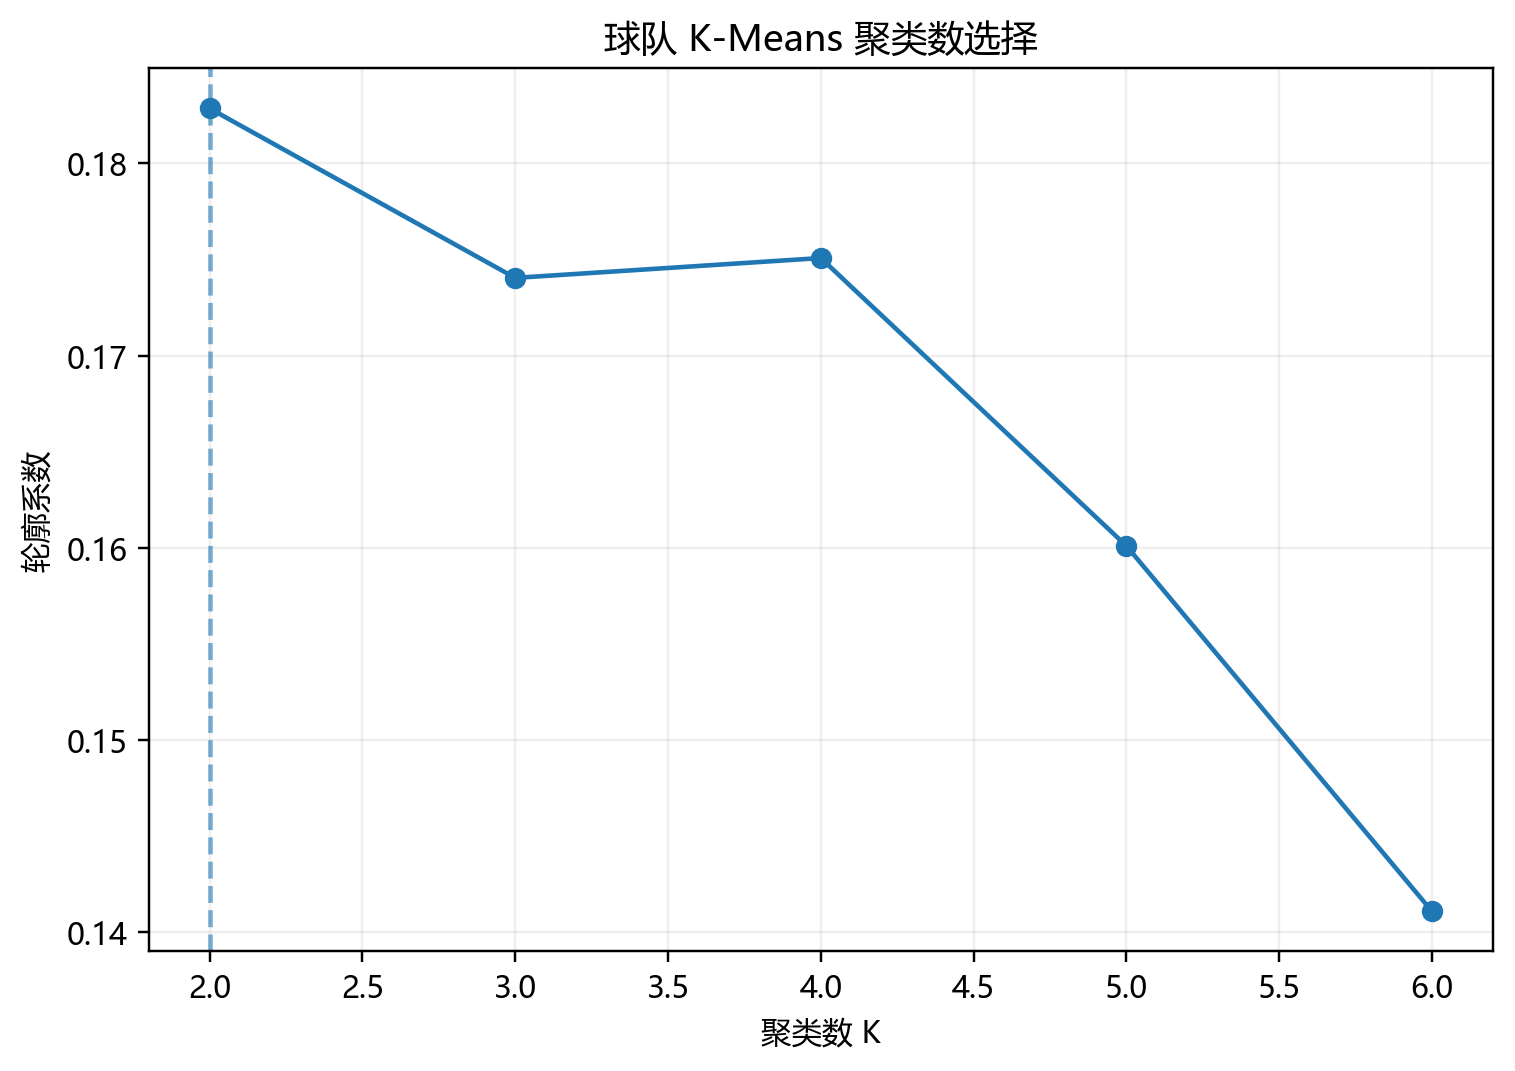

### 图02_球队聚类_PCA二维图.png

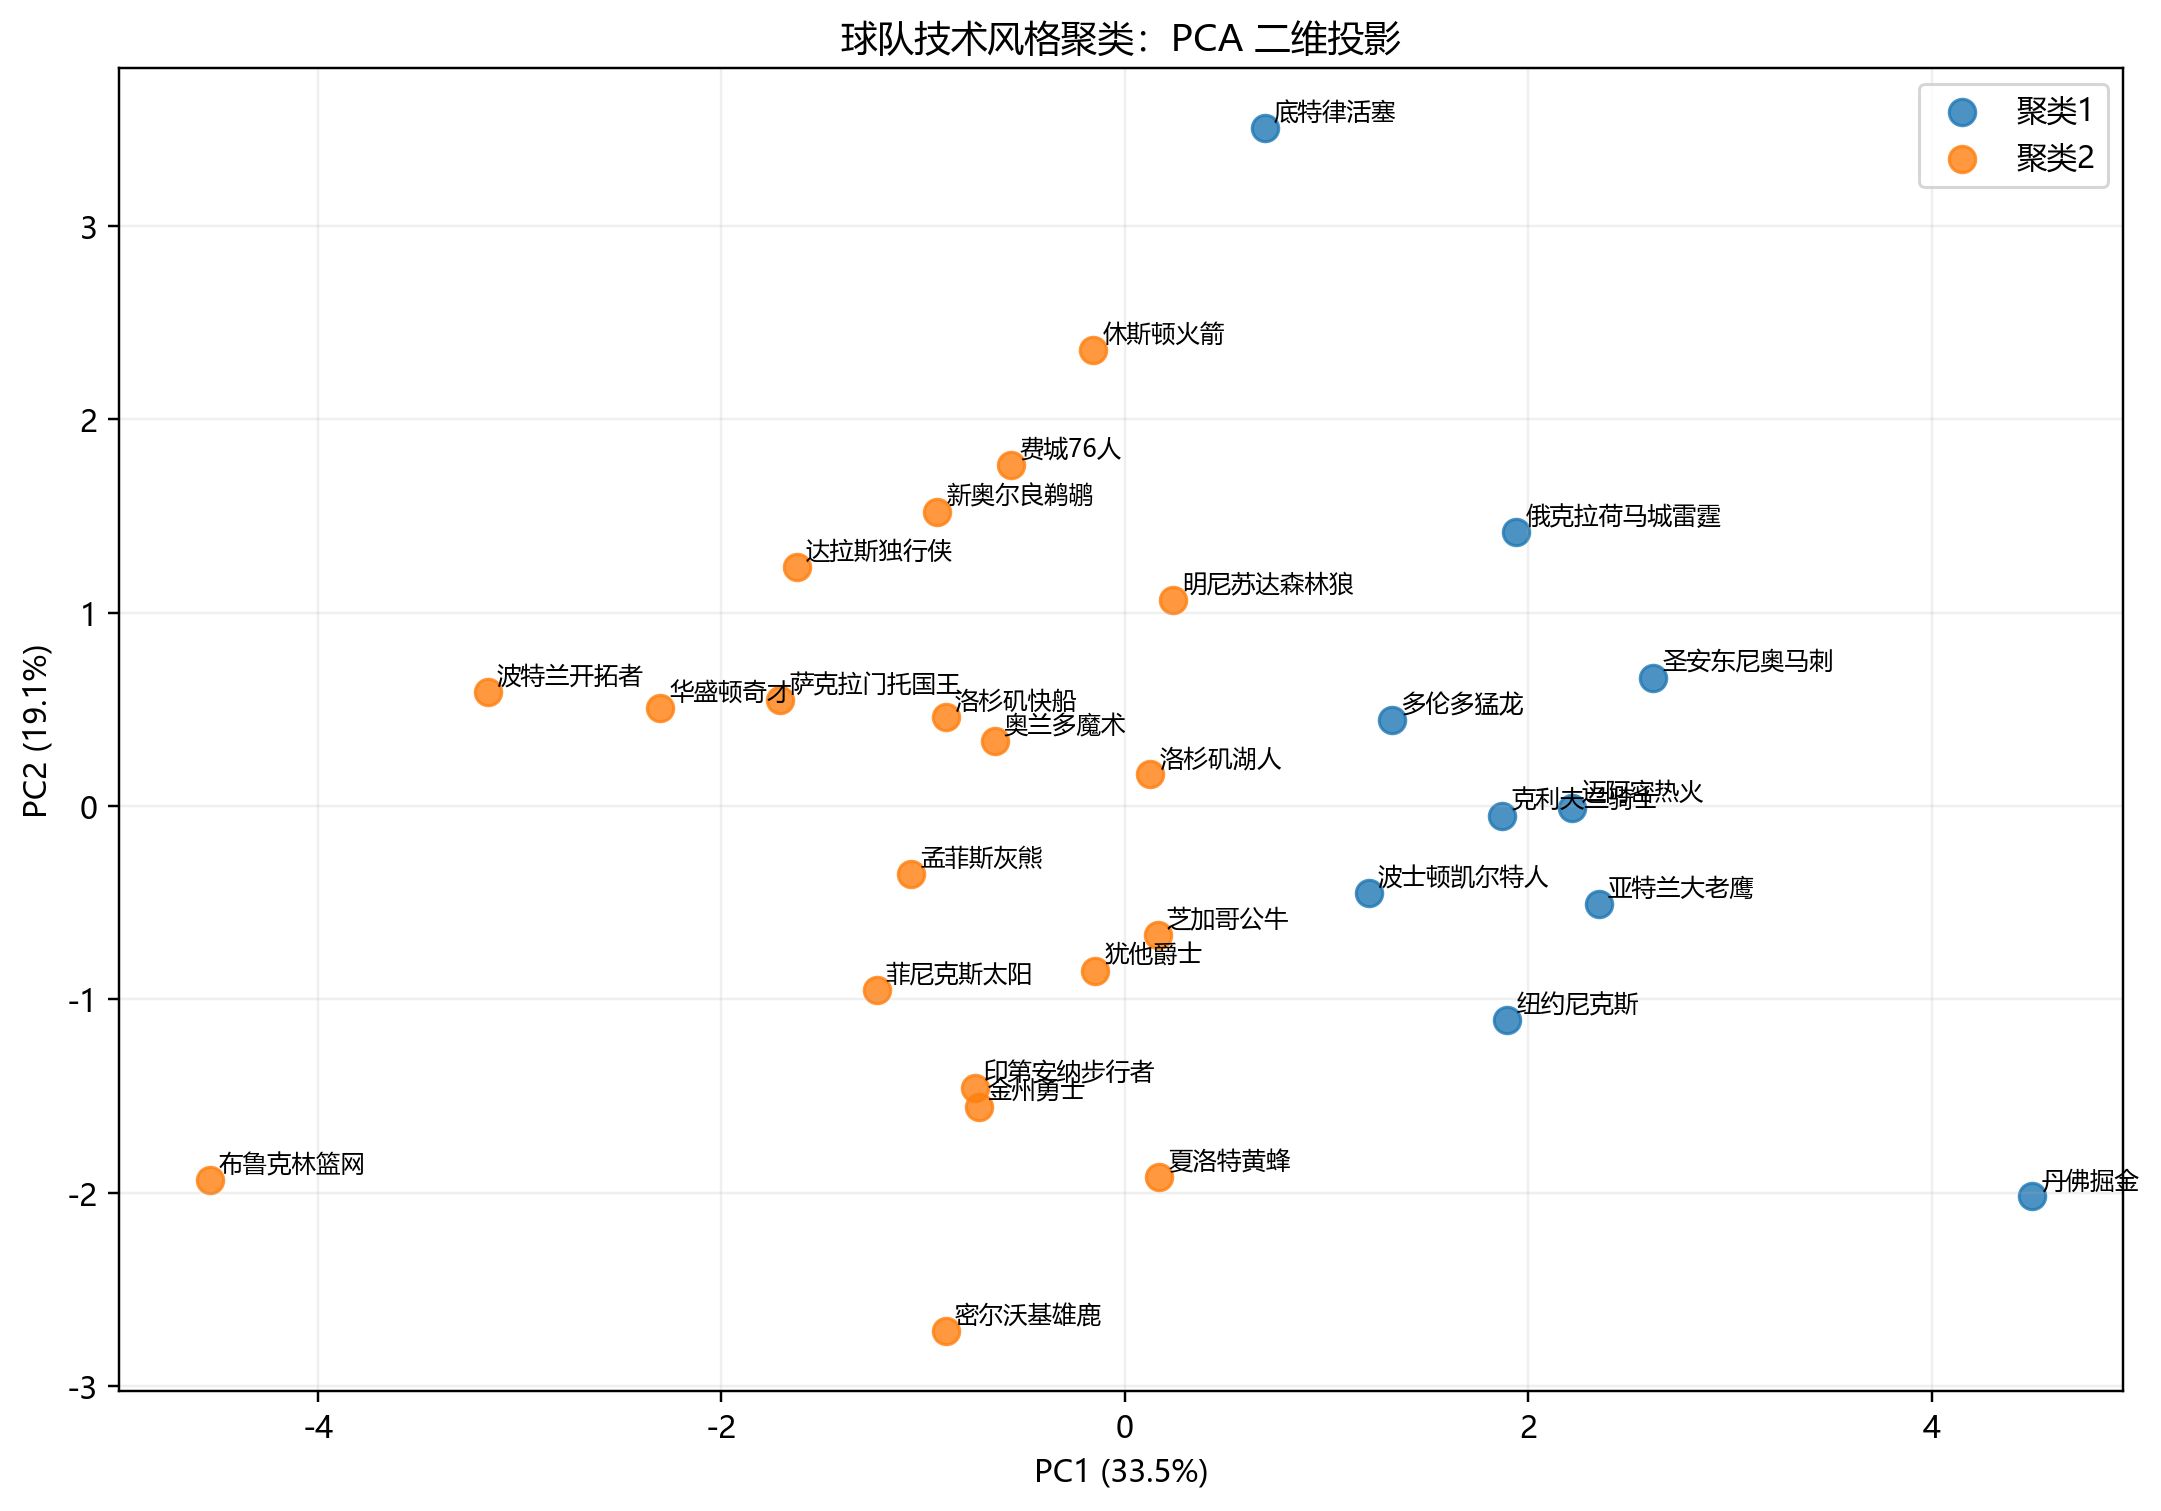

### 图05_球员聚类_PCA二维图.png

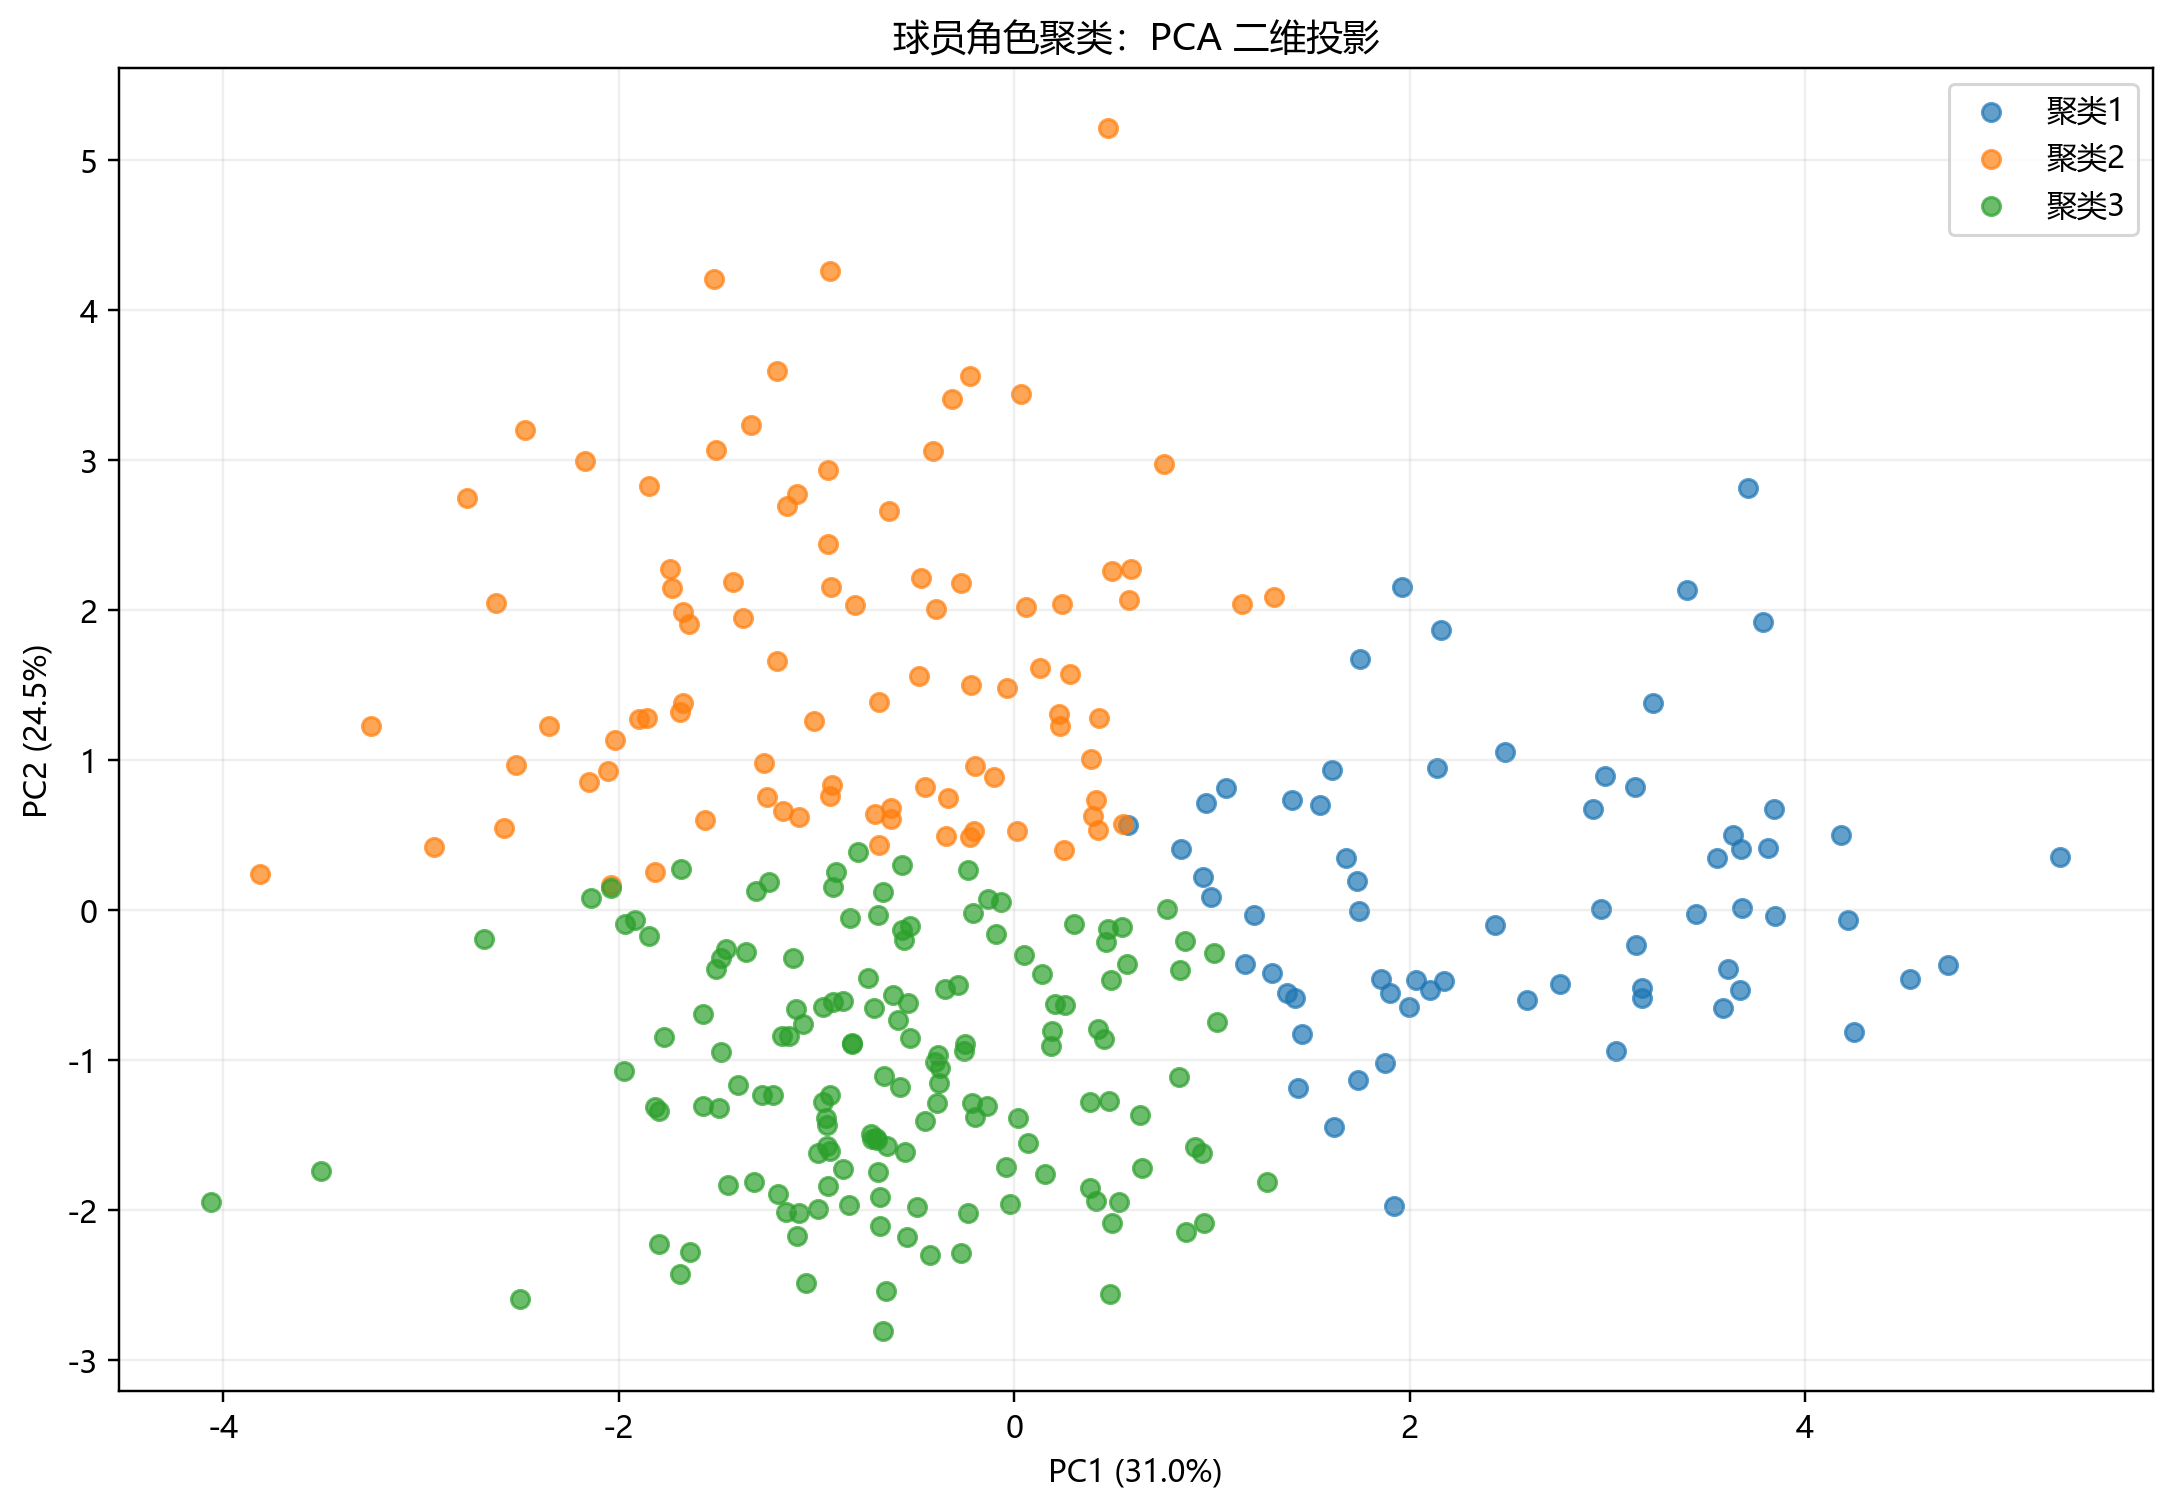

### 图07_胜率回归模型比较.png

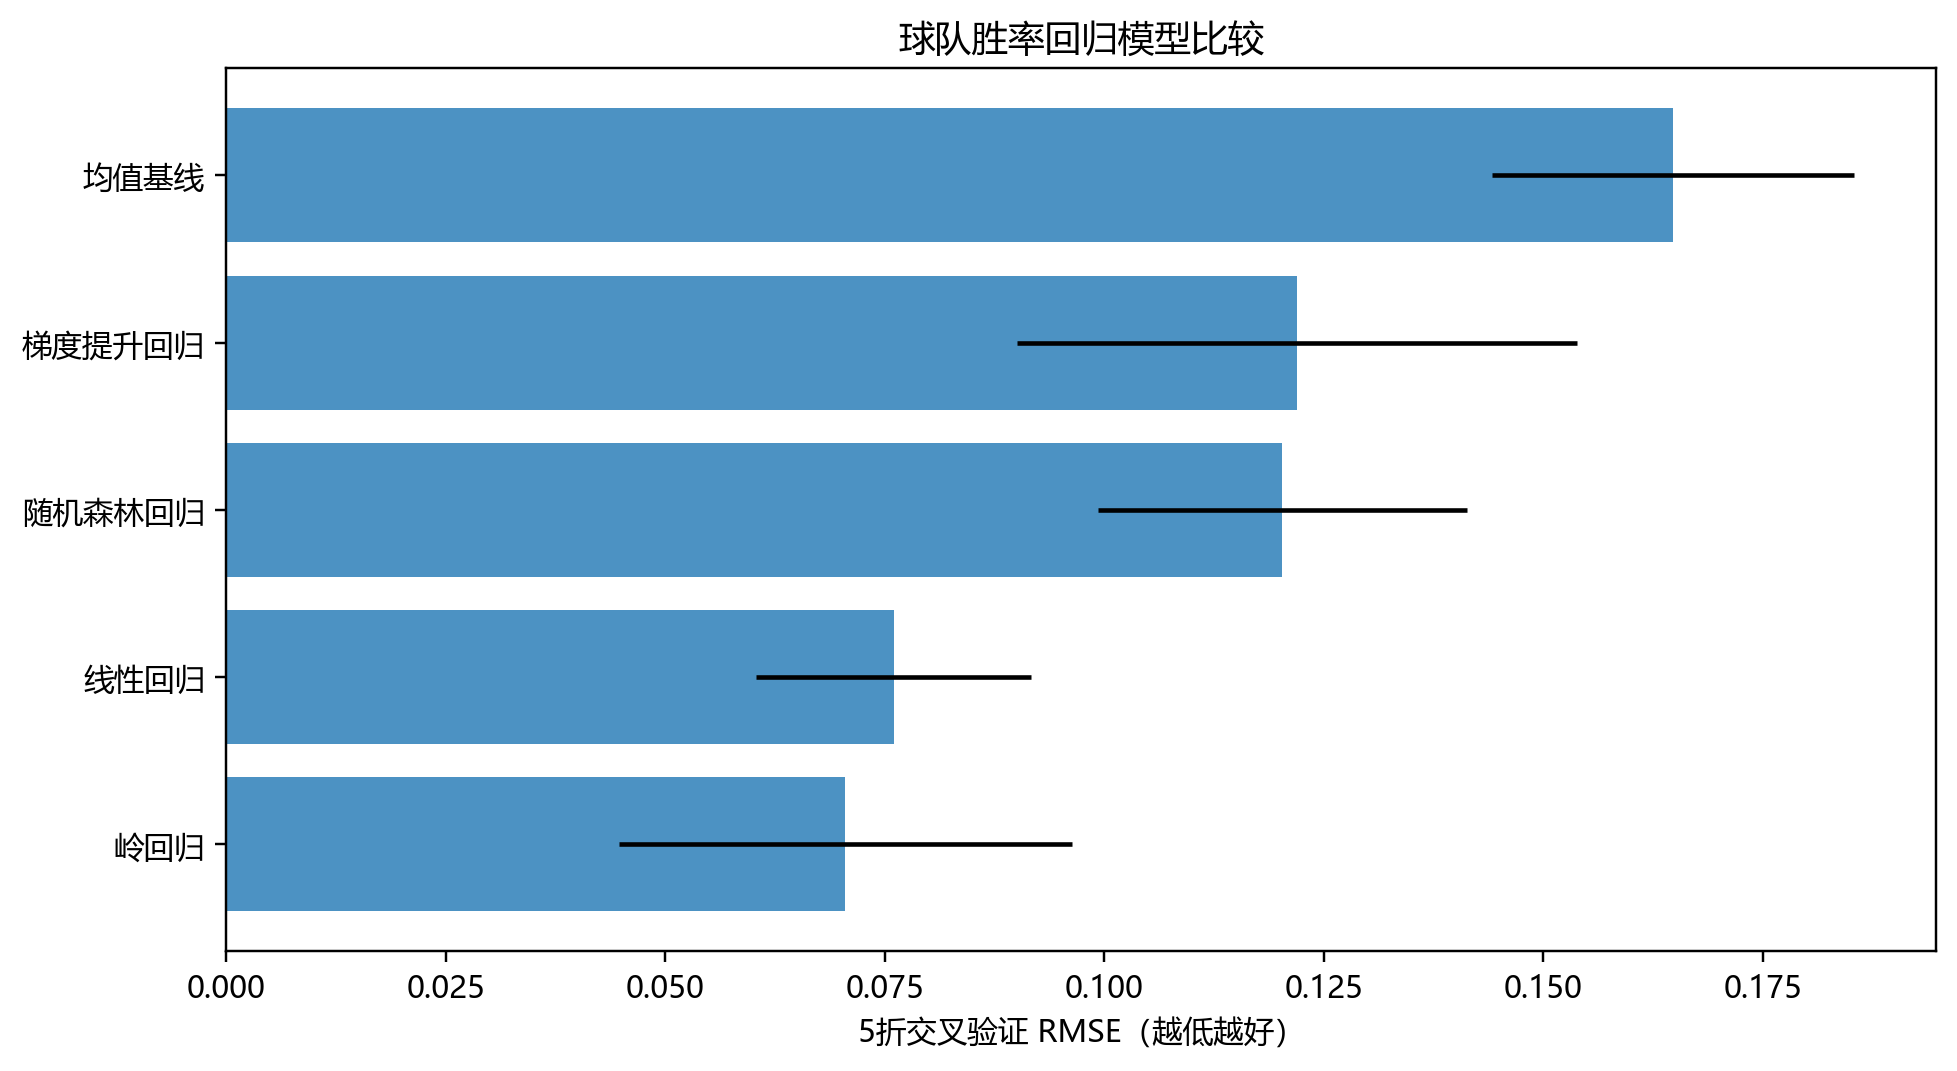

### 图08_岭回归_真实胜率与预测胜率.png

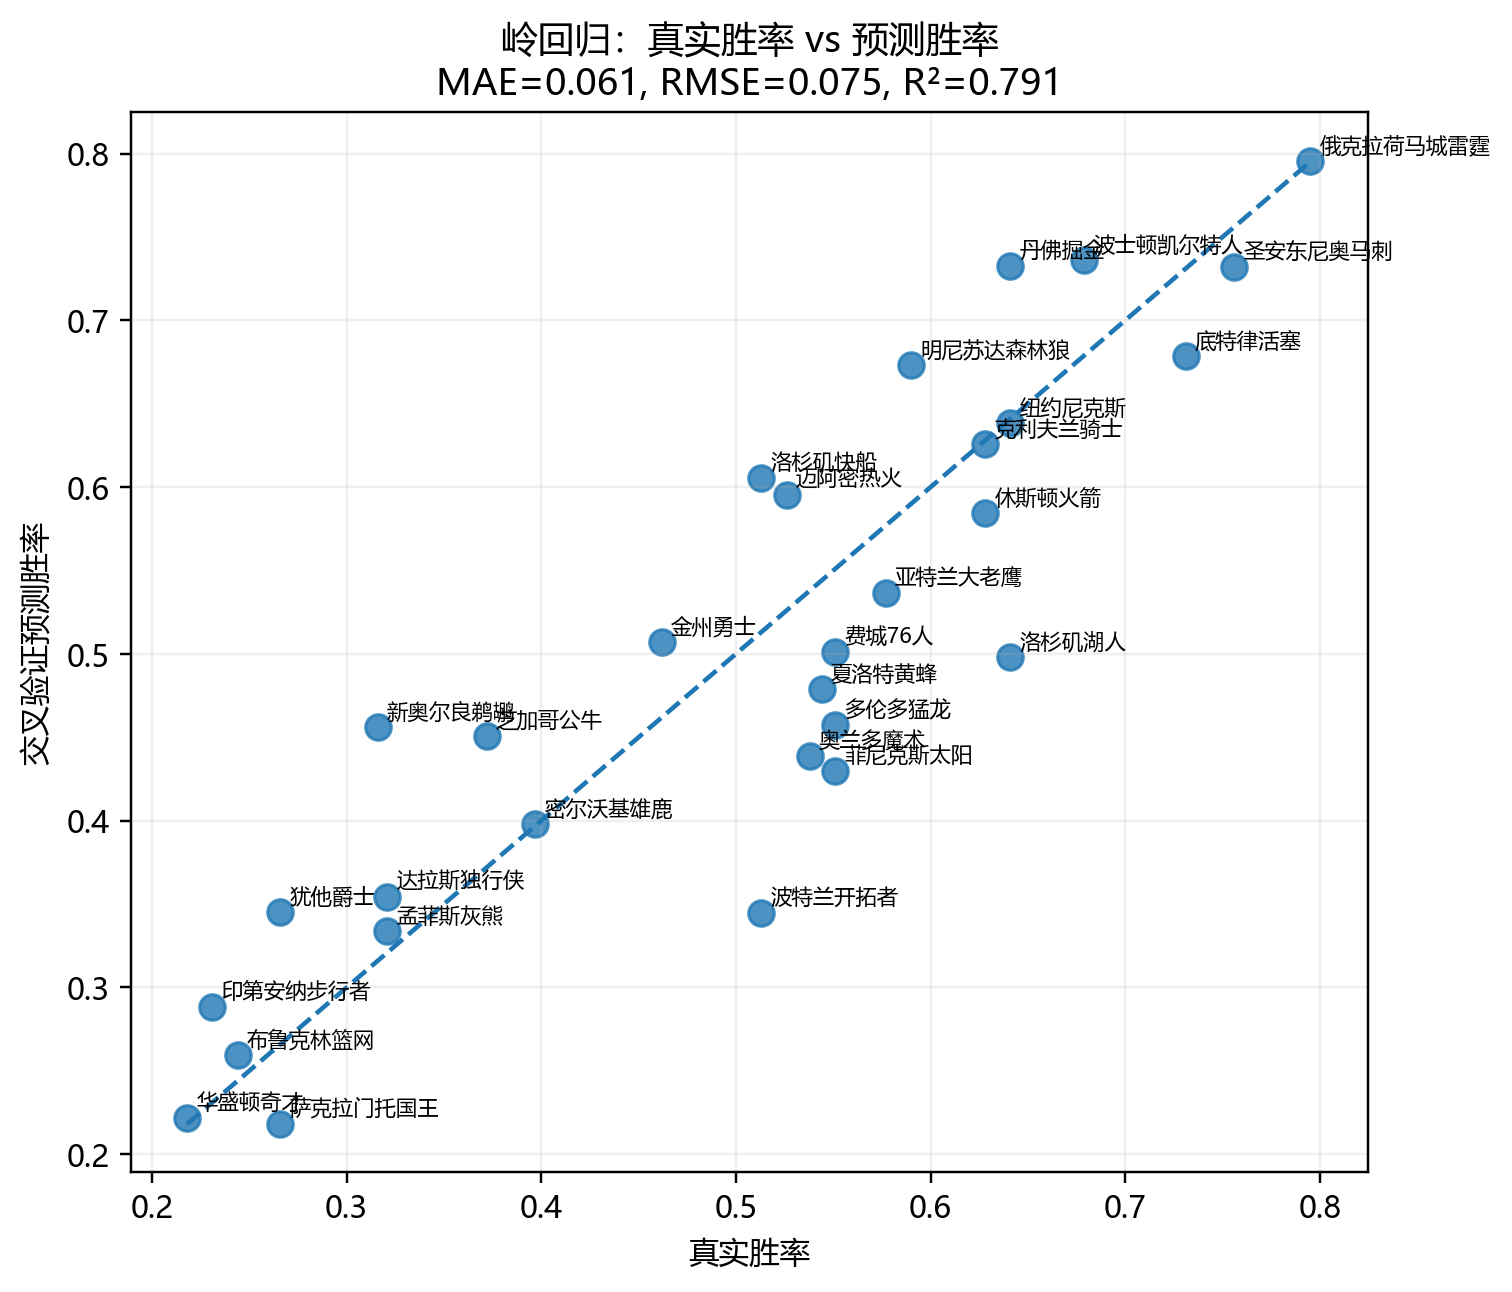

### 图10_Top10分类_ROC曲线.png

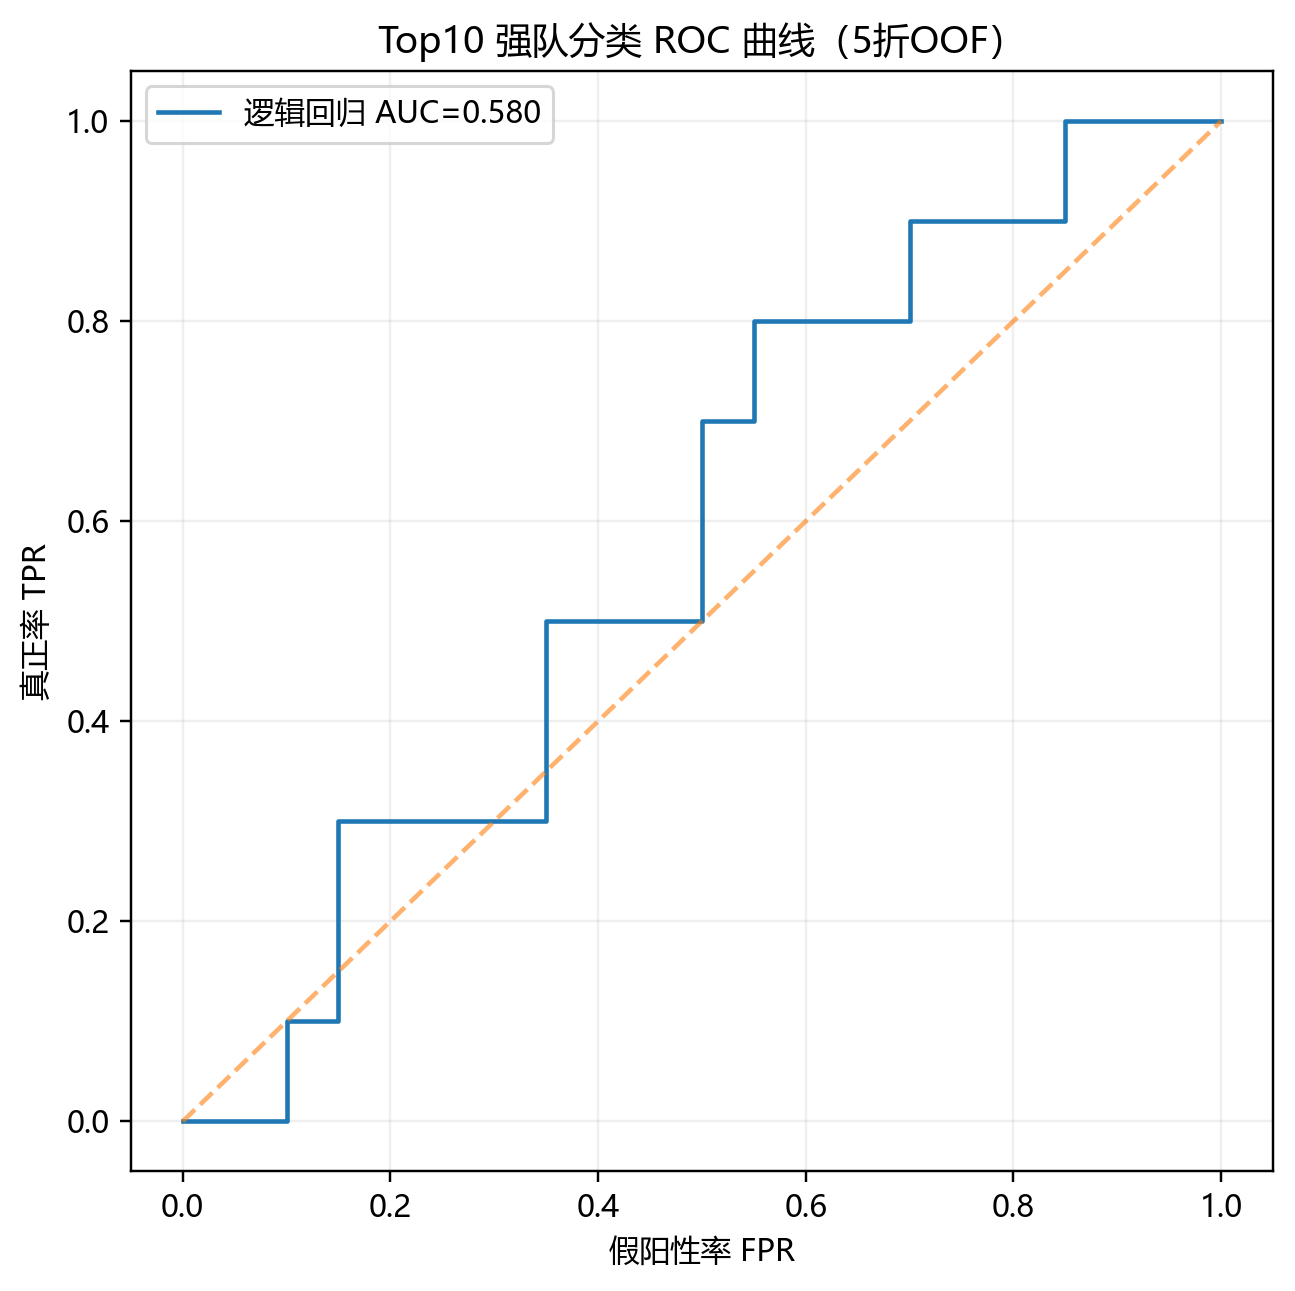

### 图11_Top10分类_混淆矩阵.png

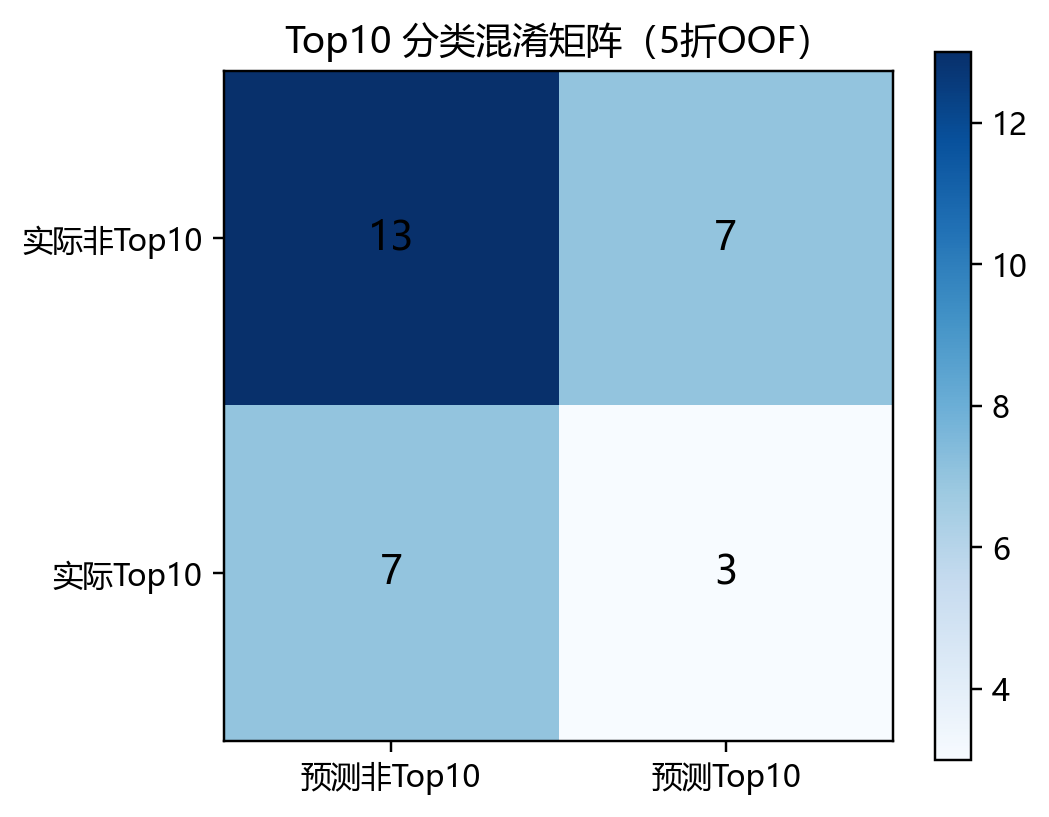

In [28]:
key_mining_images = [
    "图01_球队聚类_K值选择.png",
    "图02_球队聚类_PCA二维图.png",
    "图05_球员聚类_PCA二维图.png",
    "图07_胜率回归模型比较.png",
    "图08_岭回归_真实胜率与预测胜率.png",
    "图10_Top10分类_ROC曲线.png",
    "图11_Top10分类_混淆矩阵.png",
]

for name in key_mining_images:
    p = mining_dir / name
    if p.exists():
        display(Markdown(f"### {name}"))
        display(Image(filename=str(p)))


# 23. 项目结论与使用建议

完成 `Run All Cells` 后，项目会自动生成两个结果文件夹：

- `NBA数据分析输出`
- `NBA数据挖掘输出`

建议写报告时按照以下逻辑组织：

**数据预处理 → EDA → 球队竞争力分析 → 球员表现分析 → PCA → 聚类 → 胜率回归 → Top10 分类 → 模型评价与局限性**

### 解释注意
- 相关性不等于因果关系。
- 球队只有 30 个样本，因此回归与分类结果应视为探索性结果。
- 球员数据没有球队字段，所以当前暂不直接研究“球员结构 → 球队胜率”。
- Top10 分类样本较少，因此不要仅依据 Accuracy 判断模型效果，应同时关注 F1、Balanced Accuracy 与 ROC-AUC。
